# MCR Pairs Trading — S&P 500, Hourly Bars, 2 Years

## 1. Setup

In [1]:
import io, itertools, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats as sstats
from statsmodels.tsa.stattools import coint

np.random.seed(42)
plt.rcParams.update({"figure.figsize": (12, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

DATA_DIR = Path("./data"); DATA_DIR.mkdir(exist_ok=True)

BARS_PER_YEAR = 7 * 252                  # hourly bars, US cash session
MA_FAST, MA_SLOW = 5 * 7, 20 * 7         # 5-day / 20-day, in bars
ENTRY_Z, ENTRY_Z_HI, EXIT_Z = 1.00, 1.25, 0.25
COST = 0.0003                            # 3 bps round trip
N_PAIRS = 5
LOOKBACK_DAYS = 504
TRAIN_DAYS, TEST_DAYS = 90, 45

## 2. Universe — S&P 500

In [2]:
SP500_CSV = """Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
ADBE,Adobe Inc.,Information Technology,Application Software,"San Jose, California",1997-05-05,796343,1982
AMD,Advanced Micro Devices,Information Technology,Semiconductors,"Santa Clara, California",2017-03-20,2488,1969
AES,AES Corporation,Utilities,Independent Power Producers & Energy Traders,"Arlington, Virginia",1998-10-02,874761,1981
AFL,Aflac,Financials,Life & Health Insurance,"Columbus, Georgia",1999-05-28,4977,1955
A,Agilent Technologies,Health Care,Life Sciences Tools & Services,"Santa Clara, California",2000-06-05,1090872,1999
APD,Air Products,Materials,Industrial Gases,"Upper Macungie Township, Pennsylvania",1985-04-30,2969,1940
ABNB,Airbnb,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","San Francisco, California",2023-09-18,1559720,2008
AKAM,Akamai Technologies,Information Technology,Internet Services & Infrastructure,"Cambridge, Massachusetts",2007-07-12,1086222,1998
ALB,Albemarle Corporation,Materials,Specialty Chemicals,"Charlotte, North Carolina",2016-07-01,915913,1994
ARE,Alexandria Real Estate Equities,Real Estate,Office REITs,"Pasadena, California",2017-03-20,1035443,1994
ALGN,Align Technology,Health Care,Health Care Supplies,"Tempe, Arizona",2017-06-19,1097149,1997
ALLE,Allegion,Industrials,Building Products,"Dublin, Ireland",2013-12-02,1579241,1908
LNT,Alliant Energy,Utilities,Electric Utilities,"Madison, Wisconsin",2016-07-01,352541,1917
ALL,Allstate,Financials,Property & Casualty Insurance,"Northbrook, Illinois",1995-07-13,899051,1931
GOOGL,Alphabet Inc. (Class A),Communication Services,Interactive Media & Services,"Mountain View, California",2006-04-03,1652044,1998
GOOG,Alphabet Inc. (Class C),Communication Services,Interactive Media & Services,"Mountain View, California",2014-04-03,1652044,1998
MO,Altria,Consumer Staples,Tobacco,"Richmond, Virginia",1957-03-04,764180,1985
AMZN,Amazon,Consumer Discretionary,Broadline Retail,"Seattle, Washington",2005-11-18,1018724,1994
AMCR,Amcor,Materials,Paper & Plastic Packaging Products & Materials,"Warmley, Bristol, United Kingdom",2019-06-07,1748790,2019 (1860)
AEE,Ameren,Utilities,Multi-Utilities,"St. Louis, Missouri",1991-09-19,1002910,1902
AEP,American Electric Power,Utilities,Electric Utilities,"Columbus, Ohio",1957-03-04,4904,1906
AXP,American Express,Financials,Consumer Finance,"New York City, New York",1976-06-30,4962,1850
AIG,American International Group,Financials,Multi-line Insurance,"New York City, New York",1980-03-31,5272,1919
AMT,American Tower,Real Estate,Telecom Tower REITs,"Boston, Massachusetts",2007-11-19,1053507,1995
AWK,American Water Works,Utilities,Water Utilities,"Camden, New Jersey",2016-03-04,1410636,1886
AMP,Ameriprise Financial,Financials,Asset Management & Custody Banks,"Minneapolis, Minnesota",2005-10-03,820027,1894
AME,Ametek,Industrials,Electrical Components & Equipment,"Berwyn, Pennsylvania",2013-09-23,1037868,1930
AMGN,Amgen,Health Care,Biotechnology,"Thousand Oaks, California",1992-01-02,318154,1980
APH,Amphenol,Information Technology,Electronic Components,"Wallingford, Connecticut",2008-09-30,820313,1932
ADI,Analog Devices,Information Technology,Semiconductors,"Wilmington, Massachusetts",1999-10-12,6281,1965
AON,Aon plc,Financials,Insurance Brokers,"London, United Kingdom",1996-04-23,315293,1982 (1919)
APA,APA Corporation,Energy,Oil & Gas Exploration & Production,"Houston, Texas",1997-07-28,1841666,1954
APO,Apollo Global Management,Financials,Asset Management & Custody Banks,"New York City, New York",2024-12-23,1858681,1990
AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals","Cupertino, California",1982-11-30,320193,1977
AMAT,Applied Materials,Information Technology,Semiconductor Materials & Equipment,"Santa Clara, California",1995-03-16,6951,1967
APP,AppLovin,Information Technology,Application Software,"Palo Alto, California",2025-09-22,1751008,2012
APTV,Aptiv,Consumer Discretionary,Automotive Parts & Equipment,"Schaffhausen, Switzerland",2012-12-24,1521332,1994
ACGL,Arch Capital Group,Financials,Property & Casualty Insurance,"Hamilton, Bermuda",2022-11-01,947484,1995
ADM,Archer Daniels Midland,Consumer Staples,Agricultural Products & Services,"Chicago, Illinois",1957-03-04,7084,1902
ARES,Ares Management,Financials,Asset Management & Custody Banks,"Los Angeles, California",2025-12-11,1176948,1977
ANET,Arista Networks,Information Technology,Communications Equipment,"Santa Clara, California",2018-08-28,1596532,2004
AJG,Arthur J. Gallagher & Co.,Financials,Insurance Brokers,"Rolling Meadows, Illinois",2016-05-31,354190,1927
AIZ,Assurant,Financials,Multi-line Insurance,"Atlanta, Georgia",2007-04-10,1267238,1892
T,AT&T,Communication Services,Integrated Telecommunication Services,"Dallas, Texas",1983-11-30,732717,1983 (1885)
ATO,Atmos Energy,Utilities,Gas Utilities,"Dallas, Texas",2019-02-15,731802,1906
ADSK,Autodesk,Information Technology,Application Software,"San Francisco, California",1989-12-01,769397,1982
ADP,Automatic Data Processing,Industrials,Human Resource & Employment Services,"Roseland, New Jersey",1981-03-31,8670,1949
AZO,AutoZone,Consumer Discretionary,Automotive Retail,"Memphis, Tennessee",1997-01-02,866787,1979
AVB,AvalonBay Communities,Real Estate,Multi-Family Residential REITs,"Arlington, Virginia",2007-01-10,915912,1978
AVY,Avery Dennison,Materials,Paper & Plastic Packaging Products & Materials,"Mentor, Ohio",1987-12-31,8818,1935
AXON,Axon Enterprise,Industrials,Aerospace & Defense,"Scottsdale, Arizona",2023-05-04,1069183,1993
BKR,Baker Hughes,Energy,Oil & Gas Equipment & Services,"Houston, Texas",2017-07-07,1701605,2017
BALL,Ball Corporation,Materials,"Metal, Glass & Plastic Containers","Broomfield, Colorado",1984-10-31,9389,1880
BAC,Bank of America,Financials,Diversified Banks,"Charlotte, North Carolina",1976-06-30,70858,1998 (1923 / 1874)
BAX,Baxter International,Health Care,Health Care Equipment,"Deerfield, Illinois",1972-09-30,10456,1931
BDX,Becton Dickinson,Health Care,Health Care Equipment,"Franklin Lakes, New Jersey",1972-09-30,10795,1897
BRK.B,Berkshire Hathaway,Financials,Multi-Sector Holdings,"Omaha, Nebraska",2010-02-16,1067983,1839
BBY,Best Buy,Consumer Discretionary,Computer & Electronics Retail,"Richfield, Minnesota",1999-06-29,764478,1966
TECH,Bio-Techne,Health Care,Life Sciences Tools & Services,"Minneapolis, Minnesota",2021-08-30,842023,1976
BIIB,Biogen,Health Care,Biotechnology,"Cambridge, Massachusetts",2003-11-13,875045,1978
BLK,BlackRock,Financials,Asset Management & Custody Banks,"New York City, New York",2011-04-04,2012383,1988
BX,Blackstone Inc.,Financials,Asset Management & Custody Banks,"New York City, New York",2023-09-18,1393818,1985
XYZ,"Block, Inc.",Financials,Transaction & Payment Processing Services,none,2025-07-23,1512673,2009
BNY,BNY Mellon,Financials,Asset Management & Custody Banks,"New York City, New York",1995-03-31,1390777,1784
BA,Boeing,Industrials,Aerospace & Defense,"Arlington, Virginia",1957-03-04,12927,1916
BKNG,Booking Holdings,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Norwalk, Connecticut",2009-11-06,1075531,1996
BSX,Boston Scientific,Health Care,Health Care Equipment,"Marlborough, Massachusetts",1995-02-24,885725,1979
BMY,Bristol Myers Squibb,Health Care,Pharmaceuticals,"New York City, New York",1957-03-04,14272,1989 (1887)
AVGO,Broadcom,Information Technology,Semiconductors,"Palo Alto, California",2014-05-08,1730168,1961
BR,Broadridge Financial Solutions,Industrials,Data Processing & Outsourced Services,"Lake Success, New York",2018-06-18,1383312,1962
BRO,Brown & Brown,Financials,Insurance Brokers,"Daytona Beach, Florida",2021-09-20,79282,1939
BF.B,Brown–Forman,Consumer Staples,Distillers & Vintners,"Louisville, Kentucky",1982-10-31,14693,1870
BLDR,Builders FirstSource,Industrials,Building Products,"Irving, Texas",2023-12-18,1316835,1998
BG,Bunge Global,Consumer Staples,Agricultural Products & Services,"Chesterfield, Missouri",2023-03-15,1996862,1818
BXP,"BXP, Inc.",Real Estate,Office REITs,"Boston, Massachusetts",2006-04-03,1037540,1970
CHRW,C.H. Robinson,Industrials,Air Freight & Logistics,"Eden Prairie, Minnesota",2007-03-02,1043277,1905
CDNS,Cadence Design Systems,Information Technology,Application Software,"San Jose, California",2017-09-18,813672,1988
CPT,Camden Property Trust,Real Estate,Multi-Family Residential REITs,"Houston, Texas",2022-04-04,906345,1981
COF,Capital One,Financials,Consumer Finance,"Tysons Corner, Virginia",1998-07-01,927628,1994
CAH,Cardinal Health,Health Care,Health Care Distributors,"Dublin, Ohio",1997-05-27,721371,1971
CCL,Carnival Corporation,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Miami, Florida",1998-12-22,815097,1972
CARR,Carrier Global,Industrials,Building Products,"Palm Beach Gardens, Florida",2020-04-03,1783180,"2020 (1915, United Technologies spinoff)"
CVNA,Carvana,Consumer Discretionary,Automotive Retail,"Tempe, Arizona",2025-12-22,1690820,2012
CASY,Casey's,Consumer Staples,Food Retail,"Ankeny, Iowa",2026-04-09,726958,1967
CAT,Caterpillar Inc.,Industrials,Construction Machinery & Heavy Transportation Equipment,"Irving, Texas",1957-03-04,18230,1925
CBOE,Cboe Global Markets,Financials,Financial Exchanges & Data,"Chicago, Illinois",2017-03-01,1374310,1973
CBRE,CBRE Group,Real Estate,Real Estate Services,"Dallas, Texas",2006-11-10,1138118,1906
CDW,CDW Corporation,Information Technology,Technology Distributors,"Vernon Hills, Illinois",2019-09-23,1402057,1984
COR,Cencora,Health Care,Health Care Distributors,"Conshohocken, Pennsylvania",2001-08-30,1140859,1985
CNC,Centene Corporation,Health Care,Managed Health Care,"St. Louis, Missouri",2016-03-30,1071739,1984
CNP,CenterPoint Energy,Utilities,Multi-Utilities,"Houston, Texas",1985-07-31,1130310,1882
CF,CF Industries,Materials,Fertilizers & Agricultural Chemicals,"Deerfield, Illinois",2008-08-27,1324404,1946
CRL,Charles River Laboratories,Health Care,Life Sciences Tools & Services,"Wilmington, Massachusetts",2021-05-14,1100682,1947
SCHW,Charles Schwab Corporation,Financials,Investment Banking & Brokerage,"Westlake, Texas",1997-06-02,316709,1971
CHTR,Charter Communications,Communication Services,Cable & Satellite,"Stamford, Connecticut",2016-09-08,1091667,1993
CVX,Chevron Corporation,Energy,Integrated Oil & Gas,"Houston, Texas",1957-03-04,93410,1879
CMG,Chipotle Mexican Grill,Consumer Discretionary,Restaurants,"Newport Beach, California",2011-04-28,1058090,1993
CB,Chubb Limited,Financials,Property & Casualty Insurance,"Zurich, Switzerland",2010-07-15,896159,1985
CHD,Church & Dwight,Consumer Staples,Household Products,"Ewing, New Jersey",2015-12-29,313927,1847
CIEN,Ciena,Information Technology,Communications Equipment,"Hanover, Maryland",2026-02-09,936395,1992
CI,Cigna,Health Care,Health Care Services,"Bloomfield, Connecticut",1976-06-30,1739940,1982
CINF,Cincinnati Financial,Financials,Property & Casualty Insurance,"Fairfield, Ohio",1997-12-18,20286,1950
CTAS,Cintas,Industrials,Diversified Support Services,"Mason, Ohio",2001-03-01,723254,1929
CSCO,Cisco,Information Technology,Communications Equipment,"San Jose, California",1993-12-01,858877,1984
C,Citigroup,Financials,Diversified Banks,"New York City, New York",1988-05-31,831001,1998
CFG,Citizens Financial Group,Financials,Regional Banks,"Providence, Rhode Island",2016-01-29,759944,1828
CLX,Clorox,Consumer Staples,Household Products,"Oakland, California",1969-03-31,21076,1913
CME,CME Group,Financials,Financial Exchanges & Data,"Chicago, Illinois",2006-08-11,1156375,1848
CMS,CMS Energy,Utilities,Multi-Utilities,"Jackson, Michigan",1957-03-04,811156,1886
KO,Coca-Cola Company (The),Consumer Staples,Soft Drinks & Non-alcoholic Beverages,"Atlanta, Georgia",1957-03-04,21344,1886
CTSH,Cognizant,Information Technology,IT Consulting & Other Services,"Teaneck, New Jersey",2006-11-17,1058290,1994
COHR,Coherent Corp.,Information Technology,Electronic Components,"Saxonburg, Pennsylvania",2026-03-23,820318,1971
COIN,Coinbase,Financials,Financial Exchanges & Data,"New York City, New York",2025-05-19,1679788,2012
CL,Colgate-Palmolive,Consumer Staples,Household Products,"New York City, New York",1957-03-04,21665,1806
CMCSA,Comcast,Communication Services,Cable & Satellite,"Philadelphia, Pennsylvania",2002-11-19,1166691,1963
FIX,Comfort Systems USA,Industrials,Construction & Engineering,"Houston, Texas",2025-12-22,1035983,1997
COP,ConocoPhillips,Energy,Oil & Gas Exploration & Production,"Houston, Texas",1957-03-04,1163165,2002
ED,Consolidated Edison,Utilities,Multi-Utilities,"New York City, New York",1957-03-04,1047862,1823
STZ,Constellation Brands,Consumer Staples,Distillers & Vintners,"Rochester, New York",2005-07-01,16918,1945
CEG,Constellation Energy,Utilities,Electric Utilities,"Baltimore, Maryland",2022-02-02,1868275,1999
COO,Cooper Companies (The),Health Care,Health Care Supplies,"San Ramon, California",2016-09-23,711404,1958
CPRT,Copart,Industrials,Diversified Support Services,"Dallas, Texas",2018-07-02,900075,1982
GLW,Corning Inc.,Information Technology,Electronic Components,"Corning, New York",1995-02-27,24741,1851
CPAY,Corpay,Financials,Transaction & Payment Processing Services,"Atlanta, Georgia",2018-06-20,1175454,2000
CTVA,Corteva,Materials,Fertilizers & Agricultural Chemicals,"Indianapolis, Indiana",2019-06-03,1755672,2019
CSGP,CoStar Group,Real Estate,Real Estate Services,"Washington, D.C.",2022-09-19,1057352,1987
COST,Costco,Consumer Staples,Consumer Staples Merchandise Retail,"Issaquah, Washington",1993-10-01,909832,1976
CRH,CRH plc,Materials,Construction Materials,"Dublin, Ireland",2025-12-22,849395,1970
CRWD,CrowdStrike,Information Technology,Systems Software,"Austin, Texas",2024-06-24,1535527,2011
CCI,Crown Castle,Real Estate,Telecom Tower REITs,"Houston, Texas",2012-03-14,1051470,1994
CSX,CSX Corporation,Industrials,Rail Transportation,"Jacksonville, Florida",1957-03-04,277948,1980
CMI,Cummins,Industrials,Construction Machinery & Heavy Transportation Equipment,"Columbus, Indiana",1965-03-31,26172,1919
CVS,CVS Health,Health Care,Health Care Services,"Woonsocket, Rhode Island",1957-03-04,64803,1996
DHR,Danaher Corporation,Health Care,Life Sciences Tools & Services,"Washington, D.C.",1998-11-18,313616,1969
DRI,Darden Restaurants,Consumer Discretionary,Restaurants,"Orlando, Florida",1995-05-31,940944,1938
DDOG,Datadog,Information Technology,Application Software,"New York City, New York",2025-07-09,1561550,2010
DVA,DaVita,Health Care,Health Care Services,"Denver, Colorado",2008-07-31,927066,1979
DECK,Deckers Brands,Consumer Discretionary,Footwear,"Goleta, California",2024-03-18,910521,1973
DE,Deere & Company,Industrials,Agricultural & Farm Machinery,"Moline, Illinois",1957-03-04,315189,1837
DELL,Dell Technologies,Information Technology,"Technology Hardware, Storage & Peripherals","Round Rock, Texas",2024-09-23,1571996,2016
DAL,Delta Air Lines,Industrials,Passenger Airlines,"Atlanta, Georgia",2013-09-11,27904,1929
DVN,Devon Energy,Energy,Oil & Gas Exploration & Production,"Oklahoma City, Oklahoma",2000-08-30,1090012,1971
DXCM,Dexcom,Health Care,Health Care Equipment,"San Diego, California",2020-05-12,1093557,1999
FANG,Diamondback Energy,Energy,Oil & Gas Exploration & Production,"Midland, Texas",2018-12-03,1539838,2007
DLR,Digital Realty,Real Estate,Data Center REITs,"Austin, Texas",2016-05-18,1297996,2004
DG,Dollar General,Consumer Staples,Consumer Staples Merchandise Retail,"Goodlettsville, Tennessee",2012-12-03,29534,1939
DLTR,Dollar Tree,Consumer Staples,Consumer Staples Merchandise Retail,"Chesapeake, Virginia",2011-12-19,935703,1986
D,Dominion Energy,Utilities,Multi-Utilities,"Richmond, Virginia",2016-11-30,715957,1983
DPZ,Domino's,Consumer Discretionary,Restaurants,"Ann Arbor, Michigan",2020-05-12,1286681,1960
DASH,DoorDash,Consumer Discretionary,Specialized Consumer Services,"San Francisco, California",2025-03-24,1792789,2012
DOV,Dover Corporation,Industrials,Industrial Machinery & Supplies & Components,"Downers Grove, Illinois",1985-10-31,29905,1955
DOW,Dow Inc.,Materials,Commodity Chemicals,"Midland, Michigan",2019-04-01,1751788,2019 (1897)
DHI,D. R. Horton,Consumer Discretionary,Homebuilding,"Arlington, Texas",2005-06-22,882184,1978
DTE,DTE Energy,Utilities,Multi-Utilities,"Detroit, Michigan",1957-03-04,936340,1995
DUK,Duke Energy,Utilities,Electric Utilities,"Charlotte, North Carolina",1976-06-30,1326160,1904
DD,DuPont,Materials,Specialty Chemicals,"Wilmington, Delaware",2019-06-03,1666700,2017 (1802)
ETN,Eaton Corporation,Industrials,Electrical Components & Equipment,"Dublin, Ireland",1957-03-04,1551182,1911
EBAY,eBay Inc.,Consumer Discretionary,Broadline Retail,"San Jose, California",2002-07-22,1065088,1995
ECHO,EchoStar,Communication Services,Wireless Telecommunication Services,"Englewood, Colorado",2026-03-23,1415404,2008
ECL,Ecolab,Materials,Specialty Chemicals,"Saint Paul, Minnesota",1989-01-31,31462,1923
EIX,Edison International,Utilities,Electric Utilities,"Rosemead, California",1957-03-04,827052,1886
EW,Edwards Lifesciences,Health Care,Health Care Equipment,"Irvine, California",2011-04-01,1099800,1958
EA,Electronic Arts,Communication Services,Interactive Home Entertainment,"Redwood City, California",2002-07-22,712515,1982
ELV,Elevance Health,Health Care,Managed Health Care,"Indianapolis, Indiana",2002-07-25,1156039,2014 (1946)
EME,Emcor,Industrials,Construction & Engineering,"Norwalk, Connecticut",2025-09-22,105634,1994
EMR,Emerson Electric,Industrials,Electrical Components & Equipment,"Ferguson, Missouri",1965-03-31,32604,1890
ETR,Entergy,Utilities,Electric Utilities,"New Orleans, Louisiana",1957-03-04,65984,1913
EOG,EOG Resources,Energy,Oil & Gas Exploration & Production,"Houston, Texas",2000-11-02,821189,1999
EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,"Pittsburgh, Pennsylvania",2022-10-03,33213,1888
EFX,Equifax,Industrials,Research & Consulting Services,"Atlanta, Georgia",1997-06-19,33185,1899
EQIX,Equinix,Real Estate,Data Center REITs,"Redwood City, California",2015-03-20,1101239,1998
EQR,Equity Residential,Real Estate,Multi-Family Residential REITs,"Chicago, Illinois",2001-12-03,906107,1969
ERIE,Erie Indemnity,Financials,Insurance Brokers,"Erie, Pennsylvania",2024-09-23,922621,1925
ESS,Essex Property Trust,Real Estate,Multi-Family Residential REITs,"San Mateo, California",2014-04-02,920522,1971
EL,Estée Lauder Companies (The),Consumer Staples,Personal Care Products,"New York City, New York",2006-01-05,1001250,1946
EG,Everest Group,Financials,Reinsurance,"Hamilton, Bermuda",2017-06-19,1095073,1973
EVRG,Evergy,Utilities,Electric Utilities,"Kansas City, Missouri",2018-06-05,1711269,1909
ES,Eversource Energy,Utilities,Electric Utilities,"Hartford, Connecticut",2009-07-24,72741,1966
EXC,Exelon,Utilities,Electric Utilities,"Chicago, Illinois",1957-03-04,1109357,2000
EXE,Expand Energy,Energy,Oil & Gas Exploration & Production,"Oklahoma City, Oklahoma",2025-03-24,895126,1989
EXPE,Expedia Group,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Seattle, Washington",2007-10-02,1324424,1996
EXPD,Expeditors International,Industrials,Air Freight & Logistics,"Seattle, Washington",2007-10-10,746515,1979
EXR,Extra Space Storage,Real Estate,Self-Storage REITs,"Salt Lake City, Utah",2016-01-19,1289490,1977
XOM,ExxonMobil,Energy,Integrated Oil & Gas,"Irving, Texas",1957-03-04,34088,1999
FFIV,"F5, Inc.",Information Technology,Communications Equipment,"Seattle, Washington",2010-12-20,1048695,1996
FDS,FactSet,Financials,Financial Exchanges & Data,"Norwalk, Connecticut",2021-12-20,1013237,1978
FICO,Fair Isaac,Information Technology,Application Software,"Bozeman, Montana",2023-03-20,814547,1956
FAST,Fastenal,Industrials,Trading Companies & Distributors,"Winona, Minnesota",2008-09-15,815556,1967
FRT,Federal Realty Investment Trust,Real Estate,Retail REITs,"Rockville, Maryland",2016-02-01,34903,1962
FDX,FedEx,Industrials,Air Freight & Logistics,"Memphis, Tennessee",1980-12-31,1048911,1971
FDXF,FedEx Freight,Industrials,Cargo Ground Transportation,"Memphis, Tennessee",2026-06-01,2082247,1982
FIS,Fidelity National Information Services,Financials,Transaction & Payment Processing Services,"Jacksonville, Florida",2006-11-10,1136893,1968
FITB,Fifth Third Bancorp,Financials,Regional Banks,"Cincinnati, Ohio",1996-03-29,35527,1858
FSLR,First Solar,Information Technology,Semiconductors,"Tempe, Arizona",2022-12-19,1274494,1999
FE,FirstEnergy,Utilities,Electric Utilities,"Akron, Ohio",1997-11-28,1031296,1997
FISV,Fiserv,Financials,Transaction & Payment Processing Services,"Brookfield, Wisconsin",2001-04-02,798354,1984
FLEX,Flex Ltd.,Information Technology,Electronic Manufacturing Services,"Austin, Texas",2026-06-22,866374,1969
F,Ford Motor Company,Consumer Discretionary,Automobile Manufacturers,"Dearborn, Michigan",1957-03-04,37996,1903
FTNT,Fortinet,Information Technology,Systems Software,"Sunnyvale, California",2018-10-11,1262039,2000
FTV,Fortive,Industrials,Industrial Machinery & Supplies & Components,"Everett, Washington",2016-07-01,1659166,2016
FOXA,Fox Corporation (Class A),Communication Services,Broadcasting,"New York City, New York",2019-03-19,1754301,2019
FOX,Fox Corporation (Class B),Communication Services,Broadcasting,"New York City, New York",2019-03-19,1754301,2019
BEN,Franklin Resources,Financials,Asset Management & Custody Banks,"San Mateo, California",1998-04-30,38777,1947
FCX,Freeport-McMoRan,Materials,Copper,"Phoenix, Arizona",2011-07-01,831259,1912
GRMN,Garmin,Consumer Discretionary,Consumer Electronics,"Schaffhausen, Switzerland",2012-12-12,1121788,1989
IT,Gartner,Information Technology,IT Consulting & Other Services,"Stamford, Connecticut",2017-04-05,749251,1979
GE,GE Aerospace,Industrials,Aerospace & Defense,"Evendale, Ohio",1957-03-04,40545,1892
GEHC,GE HealthCare,Health Care,Health Care Equipment,"Chicago, Illinois",2023-01-04,1932393,1994
GEV,GE Vernova,Industrials,Heavy Electrical Equipment,"Cambridge, Massachusetts",2024-04-02,1996810,2024
GEN,Gen Digital,Information Technology,Systems Software,"Tempe, Arizona",2003-03-25,849399,1982
GNRC,Generac,Industrials,Heavy Electrical Equipment,"Waukesha, Wisconsin",2021-03-22,1474735,1959
GD,General Dynamics,Industrials,Aerospace & Defense,"Reston, Virginia",1957-03-04,40533,1899
GIS,General Mills,Consumer Staples,Packaged Foods & Meats,"Golden Valley, Minnesota",1957-03-04,40704,1856
GM,General Motors,Consumer Discretionary,Automobile Manufacturers,"Detroit, Michigan",2013-06-06,1467858,1908
GPC,Genuine Parts Company,Consumer Discretionary,Distributors,"Atlanta, Georgia",1973-12-31,40987,1925
GILD,Gilead Sciences,Health Care,Biotechnology,"Foster City, California",2004-07-01,882095,1987
GPN,Global Payments,Financials,Transaction & Payment Processing Services,"Atlanta, Georgia",2016-04-25,1123360,2000
GL,Globe Life,Financials,Life & Health Insurance,"McKinney, Texas",1989-04-30,320335,1900
GDDY,GoDaddy,Information Technology,Internet Services & Infrastructure,"Tempe, Arizona",2024-06-24,1609711,1997
GS,Goldman Sachs,Financials,Investment Banking & Brokerage,"New York City, New York",2002-07-22,886982,1869
HAL,Halliburton,Energy,Oil & Gas Equipment & Services,"Houston, Texas",1957-03-04,45012,1919
HIG,Hartford (The),Financials,Property & Casualty Insurance,"Hartford, Connecticut",1957-03-04,874766,1810
HAS,Hasbro,Consumer Discretionary,Leisure Products,"Pawtucket, Rhode Island",1984-09-30,46080,1923
HCA,HCA Healthcare,Health Care,Health Care Facilities,"Nashville, Tennessee",2015-01-27,860730,1968
DOC,Healthpeak Properties,Real Estate,Health Care REITs,"Denver, Colorado",2008-03-31,765880,1985
HSIC,Henry Schein,Health Care,Health Care Distributors,"Melville, New York",2015-03-17,1000228,1932
HSY,Hershey Company (The),Consumer Staples,Packaged Foods & Meats,"Hershey, Pennsylvania",1957-03-04,47111,1894
HPE,Hewlett Packard Enterprise,Information Technology,"Technology Hardware, Storage & Peripherals","Houston, Texas",2015-11-02,1645590,2015
HLT,Hilton Worldwide,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Tysons Corner, Virginia",2017-06-19,1585689,1919
HD,Home Depot (The),Consumer Discretionary,Home Improvement Retail,"Atlanta, Georgia",1988-03-31,354950,1978
HONA,Honeywell Aerospace,Industrials,Aerospace & Defense,"Phoenix, Arizona",2026-06-29,2089271,1914
HON,Honeywell Technologies,Industrials,Industrial Conglomerates,"Charlotte, North Carolina",1957-03-04,773840,1906
HRL,Hormel Foods,Consumer Staples,Packaged Foods & Meats,"Austin, Minnesota",2009-03-04,48465,1891
HST,Host Hotels & Resorts,Real Estate,Hotel & Resort REITs,"Bethesda, Maryland",2007-03-20,1070750,1993
HWM,Howmet Aerospace,Industrials,Aerospace & Defense,"Pittsburgh, Pennsylvania",2016-10-21,4281,1888
HPQ,HP Inc.,Information Technology,"Technology Hardware, Storage & Peripherals","Palo Alto, California",1974-12-31,47217,1939 (2015)
HUBB,Hubbell Incorporated,Industrials,Industrial Machinery & Supplies & Components,"Shelton, Connecticut",2023-10-18,48898,1888
HUM,Humana,Health Care,Managed Health Care,"Louisville, Kentucky",2012-12-10,49071,1961
HBAN,Huntington Bancshares,Financials,Regional Banks,"Columbus, Ohio; Detroit, Michigan",1997-08-28,49196,1866
HII,Huntington Ingalls Industries,Industrials,Aerospace & Defense,"Newport News, Virginia",2018-01-03,1501585,2011
IBM,IBM,Information Technology,IT Consulting & Other Services,"Armonk, New York",1957-03-04,51143,1911
IEX,IDEX Corporation,Industrials,Industrial Machinery & Supplies & Components,"Northbrook, Illinois",2019-08-09,832101,1988
IDXX,Idexx Laboratories,Health Care,Health Care Equipment,"Westbrook, Maine",2017-01-05,874716,1983
ITW,Illinois Tool Works,Industrials,Industrial Machinery & Supplies & Components,"Glenview, Illinois",1986-02-28,49826,1912
INCY,Incyte,Health Care,Biotechnology,"Wilmington, Delaware",2017-02-28,879169,1991
IR,Ingersoll Rand,Industrials,Industrial Machinery & Supplies & Components,"Davidson, North Carolina",2020-03-03,1699150,1859
PODD,Insulet Corporation,Health Care,Health Care Equipment,"Acton, Massachusetts",2023-03-15,1145197,2000
INTC,Intel,Information Technology,Semiconductors,"Santa Clara, California",1976-12-31,50863,1968
IBKR,Interactive Brokers,Financials,Investment Banking & Brokerage,"Greenwich, Connecticut",2025-08-28,1381197,1977
ICE,Intercontinental Exchange,Financials,Financial Exchanges & Data,"Atlanta, Georgia",2007-09-26,1571949,2000
IFF,International Flavors & Fragrances,Materials,Specialty Chemicals,"New York City, New York",1976-03-31,51253,1958 (1889)
IP,International Paper,Materials,Paper & Plastic Packaging Products & Materials,"Memphis, Tennessee",1957-03-04,51434,1898
INTU,Intuit,Information Technology,Application Software,"Mountain View, California",2000-12-05,896878,1983
ISRG,Intuitive Surgical,Health Care,Health Care Equipment,"Sunnyvale, California",2008-06-02,1035267,1995
IVZ,Invesco,Financials,Asset Management & Custody Banks,"Atlanta, Georgia",2008-08-21,914208,1935
INVH,Invitation Homes,Real Estate,Single-Family Residential REITs,"Dallas, Texas",2022-09-19,1687229,2012
IQV,IQVIA,Health Care,Life Sciences Tools & Services,"Durham, North Carolina",2017-08-29,1478242,1982
IRM,Iron Mountain,Real Estate,Other Specialized REITs,"Portsmouth, New Hampshire",2009-01-06,1020569,1951
JBHT,J.B. Hunt,Industrials,Cargo Ground Transportation,"Lowell, Arkansas",2015-07-01,728535,1961
JBL,Jabil,Information Technology,Electronic Manufacturing Services,"St. Petersburg, Florida",2023-12-18,898293,1966
JKHY,Jack Henry & Associates,Financials,Transaction & Payment Processing Services,"Monett, Missouri",2018-11-13,779152,1976
J,Jacobs Solutions,Industrials,Construction & Engineering,"Dallas, Texas",2007-10-26,52988,1947
JNJ,Johnson & Johnson,Health Care,Pharmaceuticals,"New Brunswick, New Jersey",1973-06-30,200406,1886
JCI,Johnson Controls,Industrials,Building Products,"Cork, Ireland",2010-08-27,833444,1885
JPM,JPMorgan Chase,Financials,Diversified Banks,"New York City, New York",1975-06-30,19617,2000 (1799 / 1871)
KVUE,Kenvue,Consumer Staples,Personal Care Products,"Skillman, New Jersey",2023-08-25,1944048,2022 (Johnson & Johnson spinoff)
KDP,Keurig Dr Pepper,Consumer Staples,Soft Drinks & Non-alcoholic Beverages,"Burlington, Massachusetts",2022-06-21,1418135,1981
KEY,KeyCorp,Financials,Regional Banks,"Cleveland, Ohio",1994-03-01,91576,1825
KEYS,Keysight Technologies,Information Technology,Electronic Equipment & Instruments,"Santa Rosa, California",2018-11-06,1601046,2014 (1939)
KMB,Kimberly-Clark,Consumer Staples,Household Products,"Irving, Texas",1957-03-04,55785,1872
KIM,Kimco Realty,Real Estate,Retail REITs,"Jericho, New York",2006-04-04,879101,1958
KMI,Kinder Morgan,Energy,Oil & Gas Storage & Transportation,"Houston, Texas",2012-05-25,1506307,1997
KKR,KKR & Co.,Financials,Asset Management & Custody Banks,"New York City, New York",2024-06-24,1404912,1976
KLAC,KLA Corporation,Information Technology,Semiconductor Materials & Equipment,"Milpitas, California",1997-09-30,319201,1975/1977 (1997)
KHC,Kraft Heinz,Consumer Staples,Packaged Foods & Meats,"Chicago, Illinois; Pittsburgh, Pennsylvania",2015-07-06,1637459,2015 (1869)
KR,Kroger,Consumer Staples,Food Retail,"Cincinnati, Ohio",1957-03-04,56873,1883
LHX,L3Harris,Industrials,Aerospace & Defense,"Melbourne, Florida",2008-09-22,202058,"2019 (L3 1997, Harris 1895)"
LH,Labcorp,Health Care,Health Care Services,"Burlington, North Carolina",2004-11-01,920148,1978
LRCX,Lam Research,Information Technology,Semiconductor Materials & Equipment,"Fremont, California",2012-06-29,707549,1980
LVS,Las Vegas Sands,Consumer Discretionary,Casinos & Gaming,"Las Vegas, Nevada",2019-10-03,1300514,1988
LDOS,Leidos,Industrials,Diversified Support Services,"Reston, Virginia",2019-08-09,1336920,1969
LEN,Lennar,Consumer Discretionary,Homebuilding,"Miami, Florida",2005-10-04,920760,1954
LII,Lennox International,Industrials,Building Products,"Richardson, Texas",2024-12-23,1069202,1895
LLY,Lilly (Eli),Health Care,Pharmaceuticals,"Indianapolis, Indiana",1970-12-31,59478,1876
LIN,Linde plc,Materials,Industrial Gases,"Guildford, United Kingdom",1992-07-01,1707925,1879
LYV,Live Nation Entertainment,Communication Services,Movies & Entertainment,"Beverly Hills, California",2019-12-23,1335258,2010
LMT,Lockheed Martin,Industrials,Aerospace & Defense,"Bethesda, Maryland",1957-03-04,936468,1995
L,Loews Corporation,Financials,Multi-line Insurance,"New York City, New York",1995-05-31,60086,1959
LOW,Lowe's,Consumer Discretionary,Home Improvement Retail,"Mooresville, North Carolina",1984-02-29,60667,1904/1946/1959
LULU,Lululemon Athletica,Consumer Discretionary,"Apparel, Accessories & Luxury Goods","Vancouver, Canada",2023-10-18,1397187,1998
LITE,Lumentum,Information Technology,Communications Equipment,"San Jose, California",2026-03-23,1633978,2015
LYB,LyondellBasell,Materials,Specialty Chemicals,"Rotterdam, Netherlands",2012-09-05,1489393,2007
MTB,M&T Bank,Financials,Regional Banks,"Buffalo, New York",2004-02-23,36270,1856
MPC,Marathon Petroleum,Energy,Oil & Gas Refining & Marketing,"Findlay, Ohio",2011-07-01,1510295,2009 (1887)
MAR,Marriott International,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Bethesda, Maryland",1998-05-29,1048286,1927
MRSH,Marsh McLennan,Financials,Insurance Brokers,"New York City, New York",1987-08-31,62709,1905
MLM,Martin Marietta Materials,Materials,Construction Materials,"Raleigh, North Carolina",2014-07-02,916076,1993
MRVL,Marvell Technology,Information Technology,Semiconductors,"Santa Clara, California",2026-06-22,1835632,1995
MAS,Masco,Industrials,Building Products,"Livonia, Michigan",1981-06-30,62996,1929
MA,Mastercard,Financials,Transaction & Payment Processing Services,"Harrison, New York",2008-07-18,1141391,1966
MKC,McCormick & Company,Consumer Staples,Packaged Foods & Meats,"Hunt Valley, Maryland",2003-03-20,63754,1889
MCD,McDonald's,Consumer Discretionary,Restaurants,"Chicago, Illinois",1970-06-30,63908,1940
MCK,McKesson Corporation,Health Care,Health Care Distributors,"Irving, Texas",1999-01-13,927653,1833
MDT,Medtronic,Health Care,Health Care Equipment,"Galway, Ireland",1986-10-31,1613103,1949
MRK,Merck & Co.,Health Care,Pharmaceuticals,"Kenilworth, New Jersey",1957-03-04,310158,1891
META,Meta Platforms,Communication Services,Interactive Media & Services,"Menlo Park, California",2013-12-23,1326801,2004
MET,MetLife,Financials,Life & Health Insurance,"New York City, New York",2000-12-11,1099219,1868
MTD,Mettler Toledo,Health Care,Life Sciences Tools & Services,"Columbus, Ohio",2016-09-06,1037646,1945
MGM,MGM Resorts,Consumer Discretionary,Casinos & Gaming,"Paradise, Nevada",2017-07-26,789570,1986
MCHP,Microchip Technology,Information Technology,Semiconductors,"Chandler, Arizona",2007-09-07,827054,1989
MU,Micron Technology,Information Technology,Semiconductors,"Boise, Idaho",1994-09-27,723125,1978
MSFT,Microsoft,Information Technology,Systems Software,"Redmond, Washington",1994-06-01,789019,1975
MAA,Mid-America Apartment Communities,Real Estate,Multi-Family Residential REITs,"Memphis, Tennessee",2016-12-02,912595,1977
MRNA,Moderna,Health Care,Biotechnology,"Cambridge, Massachusetts",2021-07-21,1682852,2010
TAP,Molson Coors Beverage Company,Consumer Staples,Brewers,"Chicago, Illinois",1976-06-30,24545,"2005 (Molson 1786, Coors 1873)"
MDLZ,Mondelez International,Consumer Staples,Packaged Foods & Meats,"Chicago, Illinois",2012-10-02,1103982,2012
MPWR,Monolithic Power Systems,Information Technology,Semiconductors,"Kirkland, Washington",2021-02-12,1280452,1997
MNST,Monster Beverage,Consumer Staples,Soft Drinks & Non-alcoholic Beverages,"Corona, California",2012-06-28,865752,2012 (1935)
MCO,Moody's Corporation,Financials,Financial Exchanges & Data,"New York City, New York",1998-07-01,1059556,1909
MS,Morgan Stanley,Financials,Investment Banking & Brokerage,"New York City, New York",1993-07-29,895421,1935
MOS,Mosaic Company (The),Materials,Fertilizers & Agricultural Chemicals,"Tampa, Florida",2011-09-26,1285785,2004 (1865 / 1909)
MSI,Motorola Solutions,Information Technology,Communications Equipment,"Chicago, Illinois",1957-03-04,68505,1928 (2011)
MSCI,MSCI Inc.,Financials,Financial Exchanges & Data,"New York City, New York",2018-04-04,1408198,1969
NDAQ,"Nasdaq, Inc.",Financials,Financial Exchanges & Data,"New York City, New York",2008-10-22,1120193,1971
NTAP,NetApp,Information Technology,"Technology Hardware, Storage & Peripherals","San Jose, California",1999-06-25,1002047,1992
NFLX,Netflix,Communication Services,Movies & Entertainment,"Los Gatos, California",2010-12-20,1065280,1997
NEM,Newmont,Materials,Gold,"Denver, Colorado",1969-06-30,1164727,1921
NWSA,News Corp (Class A),Communication Services,Publishing,"New York City, New York",2013-08-01,1564708,2013 (News Corporation 1980)
NWS,News Corp (Class B),Communication Services,Publishing,"New York City, New York",2015-09-18,1564708,2013 (News Corporation 1980)
NEE,NextEra Energy,Utilities,Multi-Utilities,"Juno Beach, Florida",1976-06-30,753308,1984 (1925)
NKE,"Nike, Inc.",Consumer Discretionary,"Apparel, Accessories & Luxury Goods","Washington County, Oregon",1988-11-30,320187,1964
NI,NiSource,Utilities,Multi-Utilities,"Merrillville, Indiana",2000-11-02,1111711,1912
NDSN,Nordson Corporation,Industrials,Industrial Machinery & Supplies & Components,"Westlake, Ohio",2022-02-15,72331,1935
NSC,Norfolk Southern,Industrials,Rail Transportation,"Atlanta, Georgia",1957-03-04,702165,1881/1894 (1980)
NTRS,Northern Trust,Financials,Asset Management & Custody Banks,"Chicago, Illinois",1998-01-30,73124,1889
NOC,Northrop Grumman,Industrials,Aerospace & Defense,"West Falls Church, Virginia[2]",1957-03-04,1133421,"1994 (Northrop 1939, Grumman 1930)"
NCLH,Norwegian Cruise Line Holdings,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Miami-Dade County, Florida[3]",2017-10-13,1513761,2011 (1966)
NRG,NRG Energy,Utilities,Independent Power Producers & Energy Traders,"Houston, Texas",2010-01-29,1013871,1992
NUE,Nucor,Materials,Steel,"Charlotte, North Carolina",1985-04-30,73309,1940
NVDA,Nvidia,Information Technology,Semiconductors,"Santa Clara, California",2001-11-30,1045810,1993
NVR,"NVR, Inc.",Consumer Discretionary,Homebuilding,"Reston, Virginia",2019-09-26,906163,1980
NXPI,NXP Semiconductors,Information Technology,Semiconductors,"Eindhoven, Netherlands",2021-03-22,1413447,1953
ORLY,O’Reilly Automotive,Consumer Discretionary,Automotive Retail,"Springfield, Missouri",2009-03-27,898173,1957
OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,"Houston, Texas",1957-03-04,797468,1920
ODFL,Old Dominion,Industrials,Cargo Ground Transportation,"Thomasville, North Carolina",2019-12-09,878927,1934
OMC,Omnicom Group,Communication Services,Advertising,"New York City, New York",1997-12-31,29989,1986
ON,ON Semiconductor,Information Technology,Semiconductors,"Phoenix, Arizona",2022-06-21,1097864,1999
OKE,Oneok,Energy,Oil & Gas Storage & Transportation,"Tulsa, Oklahoma",2010-03-15,1039684,1906
ORCL,Oracle Corporation,Information Technology,Application Software,"Austin, Texas",1989-08-31,1341439,1977
OTIS,Otis Worldwide,Industrials,Industrial Machinery & Supplies & Components,"Farmington, Connecticut",2020-04-03,1781335,"2020 (1853, United Technologies spinoff)"
PCAR,Paccar,Industrials,Construction Machinery & Heavy Transportation Equipment,"Bellevue, Washington",1980-12-31,75362,1905
PKG,Packaging Corporation of America,Materials,Paper & Plastic Packaging Products & Materials,"Lake Forest, Illinois",2017-07-26,75677,1959
PLTR,Palantir Technologies,Information Technology,Application Software,"Aventura, Florida",2024-09-23,1321655,2003
PANW,Palo Alto Networks,Information Technology,Systems Software,"Santa Clara, California",2023-06-20,1327567,2005
PSKY,Paramount Skydance Corporation,Communication Services,Movies & Entertainment,"Los Angeles, California",1994-09-30,2041610,2025 (Paramount Pictures 1912)
PH,Parker Hannifin,Industrials,Industrial Machinery & Supplies & Components,"Cleveland, Ohio",1985-11-30,76334,1917
PAYX,Paychex,Industrials,Human Resource & Employment Services,"Penfield, New York",1998-10-01,723531,1971
PYPL,PayPal,Financials,Transaction & Payment Processing Services,"San Jose, California",2015-07-20,1633917,1998
PNR,Pentair,Industrials,Industrial Machinery & Supplies & Components,"Worsley, United Kingdom",2012-10-01,77360,1966
PEP,PepsiCo,Consumer Staples,Soft Drinks & Non-alcoholic Beverages,"Purchase, New York",1957-03-04,77476,1898
PFE,Pfizer,Health Care,Pharmaceuticals,"New York City, New York",1957-03-04,78003,1849
PCG,PG&E Corporation,Utilities,Multi-Utilities,"Oakland, California",2022-10-03,1004980,1905
PM,Philip Morris International,Consumer Staples,Tobacco,"New York City, New York",2008-03-31,1413329,2008 (1847)
PSX,Phillips 66,Energy,Oil & Gas Refining & Marketing,"Houston, Texas",2012-05-01,1534701,2012 (1917)
PNW,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985
PNC,PNC Financial Services,Financials,Diversified Banks,"Pittsburgh, Pennsylvania",1988-04-30,713676,1845
PPG,PPG Industries,Materials,Specialty Chemicals,"Pittsburgh, Pennsylvania",1957-03-04,79879,1883
PPL,PPL Corporation,Utilities,Electric Utilities,"Allentown, Pennsylvania",2001-10-01,922224,1920
PFG,Principal Financial Group,Financials,Life & Health Insurance,"Des Moines, Iowa",2002-07-22,1126328,1879
PG,Procter & Gamble,Consumer Staples,Personal Care Products,"Cincinnati, Ohio",1957-03-04,80424,1837
PGR,Progressive Corporation,Financials,Property & Casualty Insurance,"Mayfield Village, Ohio",1997-08-04,80661,1937
PLD,Prologis,Real Estate,Industrial REITs,"San Francisco, California",2003-07-17,1045609,1983
PRU,Prudential Financial,Financials,Life & Health Insurance,"Newark, New Jersey",2002-07-22,1137774,1875
PEG,Public Service Enterprise Group,Utilities,Electric Utilities,"Newark, New Jersey",1957-03-04,788784,1903
PTC,PTC Inc.,Information Technology,Application Software,"Boston, Massachusetts",2021-04-20,857005,1985
PSA,Public Storage,Real Estate,Self-Storage REITs,"Glendale, California",2005-08-19,1393311,1972
PHM,PulteGroup,Consumer Discretionary,Homebuilding,"Atlanta, Georgia",1984-04-30,822416,1956
PWR,Quanta Services,Industrials,Construction & Engineering,"Houston, Texas",2009-07-01,1050915,1997
QCOM,Qualcomm,Information Technology,Semiconductors,"San Diego, California",1999-07-22,804328,1985
DGX,Quest Diagnostics,Health Care,Health Care Services,"Secaucus, New Jersey",2002-12-12,1022079,1967
Q,Qnity Electronics,Information Technology,Semiconductor Materials & Equipment,"Wilmington, Delaware",2025-11-03,2058873,2025
RL,Ralph Lauren Corporation,Consumer Discretionary,"Apparel, Accessories & Luxury Goods","New York City, New York",2007-02-02,1037038,1967
RJF,Raymond James Financial,Financials,Investment Banking & Brokerage,"St. Petersburg, Florida",2017-03-20,720005,1962
RTX,RTX Corporation,Industrials,Aerospace & Defense,"Waltham, Massachusetts",1957-03-04,101829,1922
O,Realty Income,Real Estate,Retail REITs,"San Diego, California",2015-04-07,726728,1969
REG,Regency Centers,Real Estate,Retail REITs,"Jacksonville, Florida",2017-03-02,910606,1963
REGN,Regeneron Pharmaceuticals,Health Care,Biotechnology,"Tarrytown, New York",2013-05-01,872589,1988
RF,Regions Financial Corporation,Financials,Regional Banks,"Birmingham, Alabama",1998-08-28,1281761,1971
RSG,Republic Services,Industrials,Environmental & Facilities Services,"Phoenix, Arizona",2008-12-05,1060391,1998 (1981)
RMD,ResMed,Health Care,Health Care Equipment,"San Diego, California",2017-07-26,943819,1989
RVTY,Revvity,Health Care,Health Care Equipment,"Waltham, Massachusetts",1985-05-31,31791,1937
HOOD,Robinhood Markets,Financials,Investment Banking & Brokerage,"Menlo Park, California",2025-09-22,1783879,2013
ROK,Rockwell Automation,Industrials,Electrical Components & Equipment,"Milwaukee, Wisconsin",2000-03-12,1024478,1903
ROL,"Rollins, Inc.",Industrials,Environmental & Facilities Services,"Atlanta, Georgia",2018-10-01,84839,1948
ROP,Roper Technologies,Information Technology,Electronic Equipment & Instruments,"Sarasota, Florida",2009-12-23,882835,1981
ROST,Ross Stores,Consumer Discretionary,Apparel Retail,"Dublin, California",2009-12-21,745732,1982
RCL,Royal Caribbean Group,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","Miami, Florida",2014-12-05,884887,1997
SPGI,S&P Global,Financials,Financial Exchanges & Data,"New York City, New York",1957-03-04,64040,1917
CRM,Salesforce,Information Technology,Application Software,"San Francisco, California",2008-09-15,1108524,1999
SNDK,Sandisk,Information Technology,"Technology Hardware, Storage & Peripherals","Milpitas, California",2025-11-28,2023554,1988
SBAC,SBA Communications,Real Estate,Telecom Tower REITs,"Boca Raton, Florida",2017-09-01,1034054,1989
SLB,Schlumberger,Energy,Oil & Gas Equipment & Services,"Houston, Texas",1957-03-04,87347,1926
STX,Seagate Technology,Information Technology,"Technology Hardware, Storage & Peripherals","Dublin, Ireland",2012-07-02,1137789,1979
SRE,Sempra,Utilities,Multi-Utilities,"San Diego, California",2017-03-17,1032208,1998
NOW,ServiceNow,Information Technology,Systems Software,"Santa Clara, California",2019-11-21,1373715,2003
SHW,Sherwin-Williams,Materials,Specialty Chemicals,"Cleveland, Ohio",1964-06-30,89800,1866
SPG,Simon Property Group,Real Estate,Retail REITs,"Indianapolis, Indiana",2002-06-26,1063761,2003
SWKS,Skyworks Solutions,Information Technology,Semiconductors,"Irvine, California",2015-03-12,4127,2002
SJM,J.M. Smucker Company (The),Consumer Staples,Packaged Foods & Meats,"Orrville, Ohio",2008-11-06,91419,1897
SW,Smurfit Westrock,Materials,Paper & Plastic Packaging Products & Materials,"Dublin, Ireland",2024-07-08,2005951,1934
SNA,Snap-on,Industrials,Industrial Machinery & Supplies & Components,"Kenosha, Wisconsin",1982-09-30,91440,1920
SOLV,Solventum,Health Care,Health Care Technology,"Saint Paul, Minnesota",2024-04-01,1964738,2023
SO,Southern Company,Utilities,Electric Utilities,"Atlanta, Georgia",1957-03-04,92122,1945
LUV,Southwest Airlines,Industrials,Passenger Airlines,"Dallas, Texas",1994-07-01,92380,1967
SWK,Stanley Black & Decker,Industrials,Industrial Machinery & Supplies & Components,"New Britain, Connecticut",1982-09-30,93556,1843
SBUX,Starbucks,Consumer Discretionary,Restaurants,"Seattle, Washington",2000-06-07,829224,1971
STT,State Street Corporation,Financials,Asset Management & Custody Banks,"Boston, Massachusetts",2003-03-14,93751,1792
STLD,Steel Dynamics,Materials,Steel,"Fort Wayne, Indiana",2022-12-22,1022671,1993
STE,Steris,Health Care,Health Care Equipment,"Dublin, Ireland",2019-12-23,1757898,1985
SYK,Stryker Corporation,Health Care,Health Care Equipment,"Kalamazoo, Michigan",2000-12-12,310764,1941
SMCI,Supermicro,Information Technology,"Technology Hardware, Storage & Peripherals","San Jose, California",2024-03-18,1375365,1993
SYF,Synchrony Financial,Financials,Consumer Finance,"Stamford, Connecticut",2015-11-18,1601712,2003
SNPS,Synopsys,Information Technology,Application Software,"Sunnyvale, California",2017-03-16,883241,1986
SYY,Sysco,Consumer Staples,Food Distributors,"Houston, Texas",1986-12-31,96021,1969
TMUS,T-Mobile US,Communication Services,Wireless Telecommunication Services,"Bellevue, Washington",2019-07-15,1283699,1994
TROW,T. Rowe Price,Financials,Asset Management & Custody Banks,"Baltimore, Maryland",2019-07-29,1113169,1937
TTWO,Take-Two Interactive,Communication Services,Interactive Home Entertainment,"New York City, New York",2018-03-19,946581,1993
TPR,"Tapestry, Inc.",Consumer Discretionary,"Apparel, Accessories & Luxury Goods","New York City, New York",2004-09-01,1116132,2017
TRGP,Targa Resources,Energy,Oil & Gas Storage & Transportation,"Houston, Texas",2022-10-12,1389170,2005
TGT,Target Corporation,Consumer Staples,Consumer Staples Merchandise Retail,"Minneapolis, Minnesota",1976-12-31,27419,1902
TEL,TE Connectivity,Information Technology,Electronic Manufacturing Services,"Galway, Ireland",2011-10-17,1385157,2007
TDY,Teledyne Technologies,Information Technology,Electronic Equipment & Instruments,"Thousand Oaks, California",2020-06-22,1094285,1960
TER,Teradyne,Information Technology,Semiconductor Materials & Equipment,"North Reading, Massachusetts",2020-09-21,97210,1960
TSLA,"Tesla, Inc.",Consumer Discretionary,Automobile Manufacturers,"Austin, Texas",2020-12-21,1318605,2003
TXN,Texas Instruments,Information Technology,Semiconductors,"Dallas, Texas",2001-03-12,97476,1930
TPL,Texas Pacific Land Corporation,Energy,Oil & Gas Exploration & Production,"Dallas, Texas",2024-11-26,1811074,1888
TXT,Textron,Industrials,Aerospace & Defense,"Providence, Rhode Island",1978-12-31,217346,1923
TMO,Thermo Fisher Scientific,Health Care,Life Sciences Tools & Services,"Waltham, Massachusetts",2004-08-03,97745,2006 (1902)
TJX,TJX Companies,Consumer Discretionary,Apparel Retail,"Framingham, Massachusetts",1985-09-30,109198,1987
TKO,TKO Group Holdings,Communication Services,Movies & Entertainment,"New York City, New York",2025-03-24,1973266,2023
TTD,Trade Desk (The),Communication Services,Advertising,"Ventura, California",2025-07-18,1671933,2009
TSCO,Tractor Supply,Consumer Discretionary,Other Specialty Retail,"Brentwood, Tennessee",2014-01-24,916365,1938
TT,Trane Technologies,Industrials,Building Products,"Dublin, Ireland",2010-11-17,1466258,1871
TDG,TransDigm Group,Industrials,Aerospace & Defense,"Cleveland, Ohio",2016-06-03,1260221,1993
TRV,Travelers Companies (The),Financials,Property & Casualty Insurance,"New York City, New York",2002-08-21,86312,1853
TRMB,Trimble Inc.,Information Technology,Application Software,"Westminster, Colorado",2021-01-21,864749,1978
TFC,Truist Financial,Financials,Diversified Banks,"Charlotte, North Carolina",1997-12-04,92230,1872
TYL,Tyler Technologies,Information Technology,Application Software,"Plano, Texas",2020-06-22,860731,1966
TSN,Tyson Foods,Consumer Staples,Packaged Foods & Meats,"Springdale, Arkansas",2005-08-10,100493,1935
USB,U.S. Bancorp,Financials,Diversified Banks,"Minneapolis, Minnesota",1999-11-01,36104,1968
UBER,Uber,Industrials,Passenger Ground Transportation,"San Francisco, California",2023-12-18,1543151,2009
UDR,"UDR, Inc.",Real Estate,Multi-Family Residential REITs,"Highlands Ranch, Colorado",2016-03-07,74208,1972
ULTA,Ulta Beauty,Consumer Discretionary,Other Specialty Retail,"Bolingbrook, Illinois",2016-04-18,1403568,1990
UNP,Union Pacific Corporation,Industrials,Rail Transportation,"Omaha, Nebraska",1957-03-04,100885,1862
UAL,United Airlines Holdings,Industrials,Passenger Airlines,"Chicago, Illinois",2015-09-03,100517,1967
UPS,United Parcel Service,Industrials,Air Freight & Logistics,"Sandy Springs, Georgia",2002-07-22,1090727,1907
URI,United Rentals,Industrials,Trading Companies & Distributors,"Stamford, Connecticut",2014-09-20,1067701,1997
UNH,UnitedHealth Group,Health Care,Managed Health Care,"Eden Prairie, Minnesota",1994-07-01,731766,1977
UHS,Universal Health Services,Health Care,Health Care Facilities,"King of Prussia, Pennsylvania",2014-09-20,352915,1979
VLO,Valero Energy,Energy,Oil & Gas Refining & Marketing,"San Antonio, Texas",2002-12-20,1035002,1980
VEEV,Veeva Systems,Health Care,Health Care Technology,"Pleasanton, California",2026-05-07,1393052,2007
VTR,Ventas,Real Estate,Health Care REITs,"Chicago, Illinois",2009-03-04,740260,1998
VLTO,Veralto,Industrials,Environmental & Facilities Services,"Waltham, Massachusetts",2023-10-02,1967680,2023
VRSN,Verisign,Information Technology,Internet Services & Infrastructure,"Reston, Virginia",2006-02-01,1014473,1995
VRSK,Verisk Analytics,Industrials,Research & Consulting Services,"Jersey City, New Jersey",2015-10-08,1442145,1971
VZ,Verizon,Communication Services,Integrated Telecommunication Services,"New York City, New York",1983-11-30,732712,1983 (1877)
VRTX,Vertex Pharmaceuticals,Health Care,Biotechnology,"Boston, Massachusetts",2013-09-23,875320,1989
VRT,Vertiv,Industrials,Electrical Components & Equipment,"Westerville, Ohio",2026-03-23,1674101,2016
VTRS,Viatris,Health Care,Pharmaceuticals,"Pittsburgh, Pennsylvania",2004-04-23,1792044,1961
VICI,Vici Properties,Real Estate,Hotel & Resort REITs,"New York City, New York",2022-06-08,1705696,2017
V,Visa Inc.,Financials,Transaction & Payment Processing Services,"San Francisco, California",2009-12-21,1403161,1958
VST,Vistra Corp.,Utilities,Electric Utilities,"Irving, Texas",2024-05-08,1692819,2016
VMC,Vulcan Materials Company,Materials,Construction Materials,"Birmingham, Alabama",1999-06-30,1396009,1909
WRB,W. R. Berkley Corporation,Financials,Property & Casualty Insurance,"Greenwich, Connecticut",2019-12-05,11544,1967
GWW,W. W. Grainger,Industrials,Industrial Machinery & Supplies & Components,"Lake Forest, Illinois",1981-06-30,277135,1927
WAB,Wabtec,Industrials,Construction Machinery & Heavy Transportation Equipment,"Pittsburgh, Pennsylvania",2019-02-27,943452,1999 (1869)
WMT,Walmart,Consumer Staples,Consumer Staples Merchandise Retail,"Bentonville, Arkansas",1982-08-31,104169,1962
DIS,Walt Disney Company (The),Communication Services,Movies & Entertainment,"Burbank, California",1976-06-30,1744489,1923
WBD,Warner Bros. Discovery,Communication Services,Broadcasting,"New York City, New York",2022-04-11,1437107,2022 (Warner Bros. 1923)
WM,Waste Management,Industrials,Environmental & Facilities Services,"Houston, Texas",1998-08-31,823768,1968
WAT,Waters Corporation,Health Care,Life Sciences Tools & Services,"Milford, Massachusetts",2002-01-02,1000697,1958
WEC,WEC Energy Group,Utilities,Electric Utilities,"Milwaukee, Wisconsin",2008-10-31,783325,1896
WFC,Wells Fargo,Financials,Diversified Banks,"San Francisco, California",1976-06-30,72971,1852
WELL,Welltower,Real Estate,Health Care REITs,"Toledo, Ohio",2009-01-30,766704,1970
WST,West Pharmaceutical Services,Health Care,Health Care Supplies,"Exton, Pennsylvania",2020-05-22,105770,1923
WDC,Western Digital,Information Technology,"Technology Hardware, Storage & Peripherals","San Jose, California",2009-07-01,106040,1970
WY,Weyerhaeuser,Real Estate,Timber REITs,"Seattle, Washington",1979-10-01,106535,1900
WSM,"Williams-Sonoma, Inc.",Consumer Discretionary,Homefurnishing Retail,"San Francisco, California",2025-03-24,719955,1956
WMB,Williams Companies,Energy,Oil & Gas Storage & Transportation,"Tulsa, Oklahoma",1975-03-31,107263,1908
WTW,Willis Towers Watson,Financials,Insurance Brokers,"London, United Kingdom",2016-01-05,1140536,2016
WDAY,"Workday, Inc.",Information Technology,Application Software,"Pleasanton, California",2024-12-23,1327811,2005
WYNN,Wynn Resorts,Consumer Discretionary,Casinos & Gaming,"Paradise, Nevada",2008-11-14,1174922,2002
XEL,Xcel Energy,Utilities,Multi-Utilities,"Minneapolis, Minnesota",1957-03-04,72903,1909
XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927
ZTS,Zoetis,Health Care,Pharmaceuticals,"Parsippany, New Jersey",2013-06-21,1555280,1952"""

universe = pd.read_csv(io.StringIO(SP500_CSV)).rename(
    columns={"Symbol": "ticker", "Security": "company", "GICS Sector": "sector"})
universe["ticker"] = universe["ticker"].str.replace(".", "-", regex=False).str.strip()
universe = universe[["ticker", "company", "sector"]].drop_duplicates("ticker").reset_index(drop=True)
SECTOR_MAP = dict(zip(universe["ticker"], universe["sector"]))
print(f"{len(universe)} tickers, {universe['sector'].nunique()} sectors")

503 tickers, 11 sectors


## 3. Data

In [3]:
def download_hourly(tickers, batch=40):
    cache = DATA_DIR / "sp500_close_1h_raw.csv"
    if cache.exists():
        return pd.read_csv(cache, index_col=0, parse_dates=True)
    frames = []
    for i in range(0, len(tickers), batch):
        df = yf.download(tickers[i:i + batch], period="730d", interval="1h",
                         auto_adjust=True, progress=False, threads=True)
        frames.append(df["Close"] if isinstance(df.columns, pd.MultiIndex) else df[["Close"]])
        time.sleep(1)
    close = pd.concat(frames, axis=1).sort_index()      # NaNs kept: coverage is per fold
    close = close.loc[:, ~close.columns.duplicated()]
    close.to_csv(cache)
    return close


raw = download_hourly(universe["ticker"].tolist())
raw = raw[raw.index.normalize().isin(sorted(pd.unique(raw.index.normalize()))[-LOOKBACK_DAYS:])]
print(f"{raw.shape[0]} bars x {raw.shape[1]} tickers | "
      f"{raw.index.min():%Y-%m-%d} -> {raw.index.max():%Y-%m-%d}")

3502 bars x 503 tickers | 2024-07-23 -> 2026-07-27


## 4. Signal — Ratio Z-Score and MCR

In [4]:
def ratio_zscore(a, b, fast=MA_FAST, slow=MA_SLOW):
    """z = (MA_5d(r) - MA_20d(r)) / SD_20d(r),  r = A / B.
    Every window is trailing and ends at bar t, so z[t] is knowable at t."""
    r = a / b
    return ((r.rolling(fast).mean() - r.rolling(slow).mean())
            / r.rolling(slow).std().replace(0, np.nan)).rename("z")


def mean_crossing_rate(z):
    """MCR: how often the z-score of the ratio crosses its mean (zero), per bar.
    This is the selection statistic. Higher = better."""
    s = z.dropna()
    if len(s) < 2:
        return 0.0
    sign = np.sign(s.values); sign = sign[sign != 0]
    return float(np.sum(sign[1:] != sign[:-1]) / len(s)) if len(sign) >= 2 else 0.0

## 5. Selection

In [5]:
def sector_pairs(cols, sector_map):
    by = {}
    for t in cols:
        by.setdefault(sector_map.get(t, "?"), []).append(t)
    return [p for names in by.values() for p in itertools.combinations(sorted(names), 2)]


def fold_universe(raw_px, span_idx):
    """Tickers usable for THIS fold only, so early folds cannot inherit
    knowledge of which names still had data later."""
    sub = raw_px.loc[span_idx]
    return sub[sub.columns[sub.notna().mean() >= 0.95]].ffill().dropna(axis=1)


def build_scores(px, pairs):
    """All four statistics on the TRAIN window. No filters."""
    log_p = np.log(px)
    corr = log_p.diff().dropna().corr()
    rows = []
    for a, b in pairs:
        z = ratio_zscore(px[a], px[b]).dropna()
        if len(z) < 20:
            continue
        na, nb = px[a] / px[a].iloc[0], px[b] / px[b].iloc[0]
        rows.append(dict(a=a, b=b, mcr=mean_crossing_rate(z),
                         coint_p=float(coint(log_p[a].values, log_p[b].values,
                                             trend="c", maxlag=1, autolag=None)[1]),
                         distance=float(np.sum((na - nb) ** 2)),
                         corr=float(corr.loc[a, b])))
    return pd.DataFrame(rows)


# (column, higher_is_better)
BASE_METHODS = {"MCR": ("mcr", True), "Cointegration": ("coint_p", False),
                "Distance": ("distance", False), "Correlation": ("corr", True)}
HYBRID_OF = {"Hybrid_MCR_Cointegration": "Cointegration",
             "Hybrid_MCR_Distance": "Distance",
             "Hybrid_MCR_Correlation": "Correlation"}
METHODS = list(BASE_METHODS) + list(HYBRID_OF)
MCR_FAMILY = ["MCR"] + list(HYBRID_OF)
BENCHMARKS = ["Cointegration", "Distance", "Correlation"]
CHAMPION = "Hybrid_MCR_Cointegration"


def _rank(sc, m):
    """Percentile rank oriented so BIGGER IS ALWAYS BETTER (select sorts
    descending). pandas gives the smallest value the lowest pct under
    ascending=True, so 'higher is better' wants ascending=True."""
    col, higher_is_better = BASE_METHODS[m]
    return sc[col].rank(ascending=higher_is_better, pct=True)


def method_rank(sc, m):
    """Hybrids are a 50/50 rank-percentile blend of MCR with the benchmark."""
    return (_rank(sc, m) if m in BASE_METHODS
            else 0.5 * _rank(sc, "MCR") + 0.5 * _rank(sc, HYBRID_OF[m]))


def select_pairs(sc, m, n=N_PAIRS):
    """Top n by score, no ticker reused. Keeps the score for capital weighting."""
    ranked = sc.assign(_s=method_rank(sc, m)).sort_values("_s", ascending=False)
    used, chosen = set(), []
    for _, row in ranked.iterrows():
        if row["a"] in used or row["b"] in used:
            continue
        chosen.append(row); used.update([row["a"], row["b"]])
        if len(chosen) == n:
            break
    return pd.DataFrame(chosen).reset_index(drop=True)

## 6. Trading Engine

In [6]:
def positions(z, entry=ENTRY_Z, exit_z=EXIT_Z):
    """
    z <= -entry -> +1  LONG the ratio  = BUY A, SHORT B   (A cheap vs B)
    z >= +entry -> -1  SHORT the ratio = SHORT A, BUY B   (A rich  vs B)
    exit when |z| <= exit_z (back at the mean). No stop-loss.

    z[t] uses only trailing windows ending at t; the implied position is held
    over bar t+1 and earns bar t+1's return, so no future bar is ever read.
    """
    zv = z.values; pos = np.zeros(len(zv)); st = 0
    for t in range(len(zv) - 1):
        zt = zv[t]
        if not np.isnan(zt):
            if st == 0:
                st = 1 if zt <= -entry else (-1 if zt >= entry else 0)
            elif abs(zt) <= exit_z:
                st = 0
        pos[t + 1] = st
    return pd.Series(pos, index=z.index, name="pos")


def pair_unit_return(pa, pb):
    """Return per unit of position: equal dollars long A and short B, so the
    pair earns (r_A - r_B)/2 and is dollar neutral by construction."""
    return (pa.pct_change().fillna(0) - pb.pct_change().fillna(0)) / 2.0

## 7. Capital Deployment — Rank-Weighted, Active Pairs Only

In [7]:
def deploy(P, R, scores):
    """Split capital across the pairs that are IN a trade, weighted by their
    selection-rank score, so that capital follows conviction and is not tied up
    by pairs that are currently flat.

    Causal: the weight at bar t depends on positions held over bar t, which were
    set from z at t-1, and on scores computed on the train window.

    Turnover is measured on the SIGNED WEIGHT path |W_t - W_{t-1}|, so resizing
    live positions when the active set changes is charged. Ignoring that would
    overstate this scheme.
    """
    active = (P != 0)
    S = pd.DataFrame(np.tile(scores.values, (len(P), 1)),
                     index=P.index, columns=P.columns).where(active, 0.0)
    w = S.div(S.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    W = w * P                                   # signed weight per pair
    gross = (W * R).sum(axis=1).rename("gross")
    turn = W.diff().abs().sum(axis=1).fillna(0.0).rename("turn")
    deployed = W.abs().sum(axis=1).rename("deployed")
    return W, gross, turn, deployed

## 8. Walk-Forward

In [8]:
def make_folds(index, train=TRAIN_DAYS, test=TEST_DAYS):
    d = sorted(pd.unique(index.normalize()))
    folds, s, i = [], 0, 0
    while s + train + test <= len(d):
        folds.append(dict(fold=i, tr0=d[s], tr1=d[s + train - 1],
                          te0=d[s + train], te1=d[s + train + test - 1]))
        s += test; i += 1
    return folds


def span(index, lo, hi):
    d = index.normalize()
    return index[(d >= lo) & (d <= hi)]


FOLDS = make_folds(raw.index)
G = {m: [] for m in METHODS}       # gross return, pooled OOS
U = {m: [] for m in METHODS}       # turnover,     pooled OOS
DEP = {m: [] for m in METHODS}     # capital deployed
PICKS, ZOUT, POSOUT, LEDGER, SCORES, PXCACHE, NEUTRAL = [], {}, {}, [], {}, {}, []

t0 = time.time()
for f in FOLDS:
    px = fold_universe(raw, span(raw.index, f["tr0"], f["te1"]))
    te = span(px.index, f["te0"], f["te1"])
    sc = build_scores(px.loc[span(px.index, f["tr0"], f["tr1"])],
                      sector_pairs(px.columns, SECTOR_MAP))
    SCORES[f["fold"]] = sc; PXCACHE[f["fold"]] = (px, te)
    zc = {}
    for m in METHODS:
        p = select_pairs(sc, m)
        PICKS.append(dict(fold=f["fold"], method=m,
                          pairs="; ".join(f"{r.a}/{r.b}" for r in p.itertuples())))
        cols, Pd, Rd = [], {}, {}
        for r in p.itertuples():
            key = (r.a, r.b)
            if key not in zc:
                zc[key] = ratio_zscore(px[r.a], px[r.b])
            nm = f"{r.a}/{r.b}"; cols.append(nm)
            Pd[nm] = positions(zc[key])
            Rd[nm] = pair_unit_return(px[r.a], px[r.b])
        P = pd.DataFrame(Pd)[cols]; R = pd.DataFrame(Rd)[cols]
        sco = pd.Series(method_rank(sc, m).loc[p.index].values, index=cols)
        W, gross, turn, dep = deploy(P, R, sco)
        G[m].append(gross.reindex(te)); U[m].append(turn.reindex(te))
        DEP[m].append(dep.reindex(te))

        if m == CHAMPION:
            # dollar neutrality of the whole book: each pair puts w/2 long and
            # w/2 short, so long dollars must equal short dollars every bar.
            NEUTRAL.append(float((W.abs().sum(axis=1) / 2
                                  - W.abs().sum(axis=1) / 2).abs().max()))
            for r in p.itertuples():
                nm = f"{r.a}/{r.b}"; pos = P[nm]; z = zc[(r.a, r.b)]
                la = pos * px[r.a].pct_change().fillna(0) / 2.0
                lb = -pos * px[r.b].pct_change().fillna(0) / 2.0
                chg = pos.diff().fillna(0)
                for o in pos.index[(chg != 0) & (pos != 0)]:
                    after = pos.loc[o:]; closed = after[after == 0]
                    ct = closed.index[0] if len(closed) else pos.index[-1]
                    sgn = pos.loc[o]; seg = slice(o, ct)
                    LEDGER.append(dict(
                        fold=f["fold"], pair=nm,
                        long=r.a if sgn > 0 else r.b, short=r.b if sgn > 0 else r.a,
                        pos=int(sgn), z_entry=float(z.loc[o]), z_exit=float(z.loc[ct]),
                        bars=int(len(pos.loc[seg])), weight=float(W[nm].loc[o]),
                        legA=float(la.loc[seg].sum()), legB=float(lb.loc[seg].sum()),
                        pnl=float((la + lb).loc[seg].sum())))
        if m == "MCR":
            for r in p.itertuples():
                ZOUT[(f["fold"], f"{r.a}/{r.b}")] = zc[(r.a, r.b)].reindex(te)
                POSOUT[(f["fold"], f"{r.a}/{r.b}")] = P[f"{r.a}/{r.b}"].reindex(te)
    print(f"fold {f['fold']}: universe={px.shape[1]} scored={len(sc)} "
          f"[{time.time()-t0:.0f}s]", flush=True)

G = {m: pd.concat(v).sort_index() for m, v in G.items()}
U = {m: pd.concat(v).sort_index() for m, v in U.items()}
DEP = {m: pd.concat(v).sort_index() for m, v in DEP.items()}
NET = {m: G[m] - U[m] * (COST / 2.0) for m in METHODS}
print(f"\n{len(FOLDS)} folds, {len(NET['MCR'])} pooled OOS bars, done in {time.time()-t0:.0f}s")
print(f"average capital deployed ({CHAMPION}): {DEP[CHAMPION].mean():.1%}")

fold 0: universe=489 scored=12988 [21s]


fold 1: universe=490 scored=13060 [41s]


fold 2: universe=491 scored=13080 [60s]


fold 3: universe=492 scored=13153 [80s]


fold 4: universe=493 scored=13225 [98s]


fold 5: universe=493 scored=13225 [117s]


fold 6: universe=493 scored=13173 [135s]


fold 7: universe=493 scored=13173 [154s]


fold 8: universe=495 scored=13319 [171s]



9 folds, 2810 pooled OOS bars, done in 171s
average capital deployed (Hybrid_MCR_Cointegration): 98.6%


## 9. Performance

In [9]:
def metrics(r):
    r = r.dropna(); eq = (1 + r).cumprod(); yrs = len(r) / BARS_PER_YEAR
    dd = (eq / eq.cummax() - 1).min(); down = r[r < 0].std()
    ann = r.mean() * BARS_PER_YEAR; vol = r.std() * np.sqrt(BARS_PER_YEAR)
    return dict(Total_Return=float(eq.iloc[-1] - 1),
                CAGR=float(eq.iloc[-1] ** (1 / yrs) - 1),
                Ann_Vol=float(vol),
                Sharpe=float(ann / vol) if vol > 0 else np.nan,
                Sortino=float(ann / (down * np.sqrt(BARS_PER_YEAR))) if down > 0 else np.nan,
                Max_Drawdown=float(dd),
                Calmar=float((eq.iloc[-1] ** (1 / yrs) - 1) / abs(dd)) if dd < 0 else np.nan,
                Hit_Ratio=float((r > 0).mean()),
                Skew=float(sstats.skew(r)),
                Kurtosis=float(sstats.kurtosis(r, fisher=False)))


PERF = pd.DataFrame({m: metrics(NET[m]) for m in METHODS}).T
PERF.sort_values("Sharpe", ascending=False).round(4)

,Total_Return,CAGR,Ann_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Hit_Ratio,Skew,Kurtosis
Hybrid_MCR_Cointegration,0.4819,0.2801,0.1259,2.0234,2.9088,-0.0654,4.2824,0.5146,4.4568,113.4613
Cointegration,0.1354,0.0830,0.1209,0.7195,0.9090,-0.1094,0.7587,0.4989,0.2308,24.4798
MCR,0.0791,0.0489,0.1289,0.4351,0.5356,-0.1551,0.3154,0.5053,-0.2384,41.2096
Hybrid_MCR_Correlation,0.0092,0.0058,0.0683,0.1185,0.1548,-0.0730,0.0792,0.4954,0.4850,28.5340
Hybrid_MCR_Distance,0.0001,0.0001,0.0654,0.0339,0.0413,-0.0748,0.0010,0.4961,0.1004,37.2537
Distance,-0.0008,-0.0005,0.0371,0.0051,0.0065,-0.0261,-0.0190,0.5053,0.7224,46.8915
Correlation,-0.0522,-0.0331,0.0395,-0.8326,-0.9961,-0.0845,-0.3916,0.5057,-1.0700,21.4630


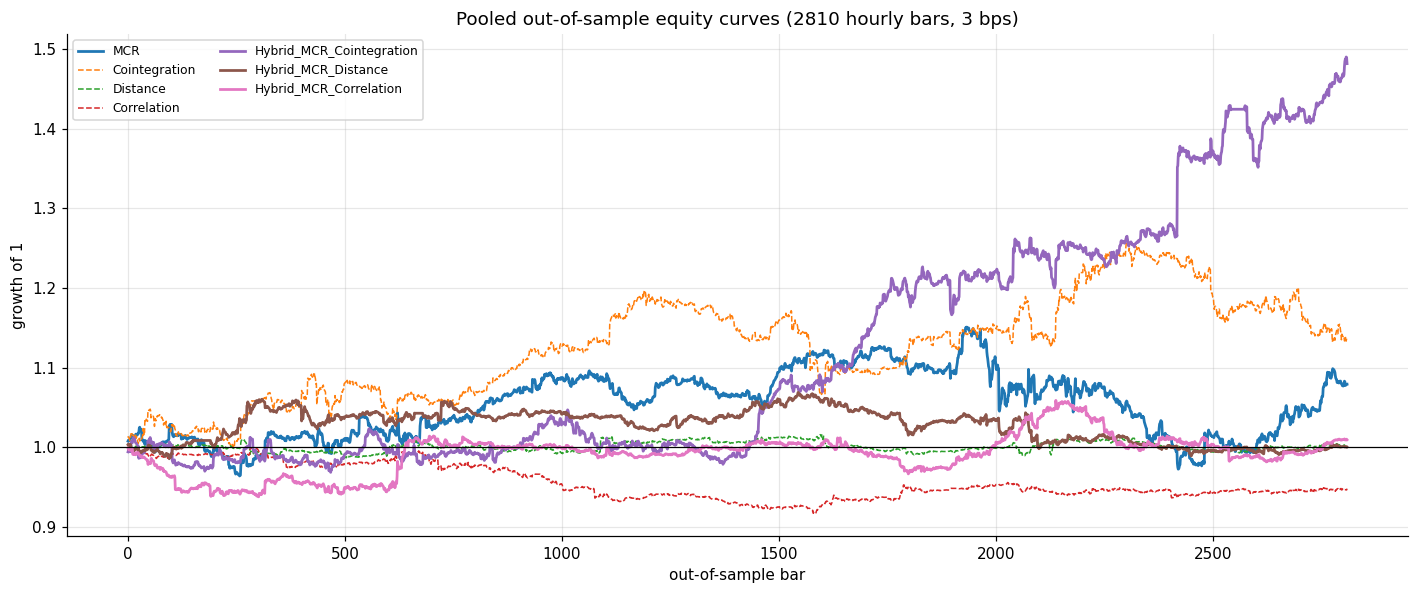

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.5))
for m in METHODS:
    ax.plot((1 + NET[m]).cumprod().values, lw=1.8 if m in MCR_FAMILY else 1.0,
            ls="-" if m in MCR_FAMILY else "--", label=m)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_title(f"Pooled out-of-sample equity curves ({len(NET['MCR'])} hourly bars, 3 bps)")
ax.set_xlabel("out-of-sample bar"); ax.set_ylabel("growth of 1")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 10. Trade Ledger — One Long, One Short per Signal

In [11]:
L = pd.DataFrame(LEDGER)
ok_distinct = bool((L["long"] != L["short"]).all())
ok_onehot = bool(L["pos"].abs().eq(1).all())
ok_legs = float((L["legA"] + L["legB"] - L["pnl"]).abs().max())
ok_dir = bool((((L["pos"] > 0) & (L["z_entry"] <= -ENTRY_Z)) |
               ((L["pos"] < 0) & (L["z_entry"] >= ENTRY_Z))).all())
ok_neutral = float(np.max(NEUTRAL))

print(f"trades: {len(L)}   long: {int((L['pos']>0).sum())}   short: {int((L['pos']<0).sum())}")
print(f"every trade has a distinct long and short ticker : {ok_distinct}")
print(f"every trade is exactly one long + one short leg  : {ok_onehot}")
print(f"legA + legB reproduces pair P&L (max error)      : {ok_legs:.2e}")
print(f"long only when z <= -{ENTRY_Z}, short only when z >= +{ENTRY_Z} : {ok_dir}")
print(f"book dollar-neutral every bar (max imbalance)    : {ok_neutral:.2e}")
L.head(12).round(5)

trades: 242   long: 113   short: 129
every trade has a distinct long and short ticker : True
every trade is exactly one long + one short leg  : True
legA + legB reproduces pair P&L (max error)      : 0.00e+00
long only when z <= -1.0, short only when z >= +1.0 : True
book dollar-neutral every bar (max imbalance)    : 0.00e+00


,fold,pair,long,short,pos,z_entry,z_exit,bars,weight,legA,legB,pnl
0,0,ADP/WM,WM,ADP,-1,1.12404,0.20196,146,-0.34483,-0.00258,-0.00626,-0.00885
1,0,ADP/WM,WM,ADP,-1,1.02157,0.07829,109,-1.00000,-0.00643,0.02698,0.02055
2,0,ADP/WM,ADP,WM,1,-1.04565,-0.18966,23,1.00000,0.02699,-0.01235,0.01464
3,0,ADP/WM,ADP,WM,1,-1.04161,-0.12129,38,0.47308,-0.00806,0.01880,0.01074
4,0,ADP/WM,WM,ADP,-1,1.06229,0.16363,122,-0.25135,0.01753,-0.01727,0.00026
5,0,ADP/WM,ADP,WM,1,-1.03993,-0.18321,61,0.34907,0.02331,-0.00756,0.01576
6,0,EW/VRTX,VRTX,EW,-1,1.16422,0.23683,59,-1.00000,0.00207,-0.01052,-0.00845
7,0,EW/VRTX,VRTX,EW,-1,1.01961,0.18252,34,-0.37708,0.01759,-0.00246,0.01513
8,0,EW/VRTX,EW,VRTX,1,-1.03311,-0.15598,55,1.00000,0.03390,0.02328,0.05718
9,0,EW/VRTX,VRTX,EW,-1,1.06565,0.20378,232,-0.58622,-0.00854,-0.03470,-0.04324


## 11. Diebold-Mariano Tests

In [12]:
def diebold_mariano(d, h=1):
    """Newey-West HAC long-run variance (automatic bandwidth), the
    Harvey-Leybourne-Newbold small-sample correction, and a t reference."""
    d = np.asarray(d, float); d = d[~np.isnan(d)]
    T = len(d); lag = max(1, int(np.floor(4 * (T / 100) ** (2 / 9))))
    dc = d - d.mean(); lrv = (dc @ dc) / T
    for k in range(1, lag + 1):
        lrv += 2 * (1 - k / (lag + 1)) * (dc[k:] @ dc[:-k]) / T
    dm = d.mean() / np.sqrt(lrv / T)
    hln = dm * np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    return hln, float(2 * (1 - sstats.t.cdf(abs(hln), df=T - 1))), lag, T


def dm_bootstrap(d, n_boot=5000, seed=42):
    """Circular block bootstrap of the null E[d]=0 (Politis-Romano); robust to
    the heavy tails that make the normal reference unreliable here."""
    d = np.asarray(d, float); d = d[~np.isnan(d)]
    rng = np.random.default_rng(seed); T = len(d); blk = max(5, int(T ** (1 / 3)))
    obs = d.mean(); dc = d - obs; nb = int(np.ceil(T / blk)); offs = np.arange(blk)
    means = np.empty(n_boot)
    for i in range(n_boot):
        idx = (rng.integers(0, T, nb)[:, None] + offs[None, :]).ravel()[:T] % T
        means[i] = dc[idx].mean()
    return float((np.abs(means) >= abs(obs)).mean()), blk


def holm(p):
    p = np.asarray(p, float); k = len(p); out = np.empty(k); run = 0.0
    for i, idx in enumerate(np.argsort(p)):
        run = max(run, min((k - i) * p[idx], 1.0)); out[idx] = run
    return out


rows = []
for b in BENCHMARKS:
    d = (NET[CHAMPION] - NET[b]).dropna().values
    hln, p, lag, T = diebold_mariano(d)
    pb, blk = dm_bootstrap(d)
    rows.append(dict(A=CHAMPION, B=b, T=T, dm_hln=hln, p_hln=p, p_boot=pb,
                     hac_lag=lag, block=blk))
DM = pd.DataFrame(rows)
DM["holm_k3"] = holm(DM["p_hln"].values)
DM["reject_5pct"] = DM["holm_k3"] < 0.05
# The rank-weighted active-deployment scheme was chosen after comparing 8
# configurations (4 schemes x 2 pair counts). Correcting only over the 3
# benchmarks ignores that search, so the wider correction is reported alongside.
DM["holm_k24_search"] = np.minimum(DM["p_hln"] * 24, 1.0)
print(f"Rejected at 5%, Holm over k=3        : {int(DM['reject_5pct'].sum())}/3")
print(f"Rejected at 5%, Holm over the k=24 search: {int((DM['holm_k24_search']<0.05).sum())}/3")
DM.round(4)

Rejected at 5%, Holm over k=3        : 2/3
Rejected at 5%, Holm over the k=24 search: 0/3


,A,B,T,dm_hln,p_hln,p_boot,hac_lag,block,holm_k3,reject_5pct,holm_k24_search
0,Hybrid_MCR_Cointegration,Cointegration,2810,1.3139,0.1890,0.1868,8,14,0.1890,False,1.0000
1,Hybrid_MCR_Cointegration,Distance,2810,2.4001,0.0165,0.0178,8,14,0.0329,True,0.3950
2,Hybrid_MCR_Cointegration,Correlation,2810,2.7031,0.0069,0.0084,8,14,0.0207,True,0.1659


## 12. Cost Sensitivity

In [13]:
COSTS = [0, 1, 2, 3, 5, 10]
REPORT = [CHAMPION] + BENCHMARKS
rows = {}
for m in REPORT:
    r = {}
    for cb in COSTS:
        s = (G[m] - U[m] * (cb / 10000.0 / 2.0)).dropna()
        r[f"ret_{cb}bps"] = float((1 + s).prod() - 1)
        r[f"sharpe_{cb}bps"] = float(s.mean() / s.std() * np.sqrt(BARS_PER_YEAR))
    # cost enters linearly and the weight path is cost-independent, so this is exact
    r["breakeven_bps"] = float(2e4 * G[m].sum() / U[m].sum())
    rows[m] = r
COST_TBL = pd.DataFrame(rows).T
COST_TBL[[f"ret_{c}bps" for c in COSTS] + ["breakeven_bps"]].round(4)

,ret_0bps,ret_1bps,ret_2bps,ret_3bps,ret_5bps,ret_10bps,breakeven_bps
Hybrid_MCR_Cointegration,0.5067,0.4984,0.4901,0.4819,0.4657,0.4258,76.5708
Cointegration,0.1560,0.1491,0.1422,0.1354,0.1218,0.0886,26.0540
Distance,0.0147,0.0095,0.0043,-0.0008,-0.0110,-0.0361,3.0589
Correlation,-0.0376,-0.0425,-0.0474,-0.0522,-0.0618,-0.0854,-7.2973


In [14]:
COST_TBL[[f"sharpe_{c}bps" for c in COSTS]].round(3)

,sharpe_0bps,sharpe_1bps,sharpe_2bps,sharpe_3bps,sharpe_5bps,sharpe_10bps
Hybrid_MCR_Cointegration,2.106,2.079,2.051,2.023,1.968,1.830
Cointegration,0.813,0.782,0.751,0.719,0.657,0.501
Distance,0.266,0.179,0.092,0.005,-0.169,-0.601
Correlation,-0.591,-0.671,-0.752,-0.833,-0.993,-1.392


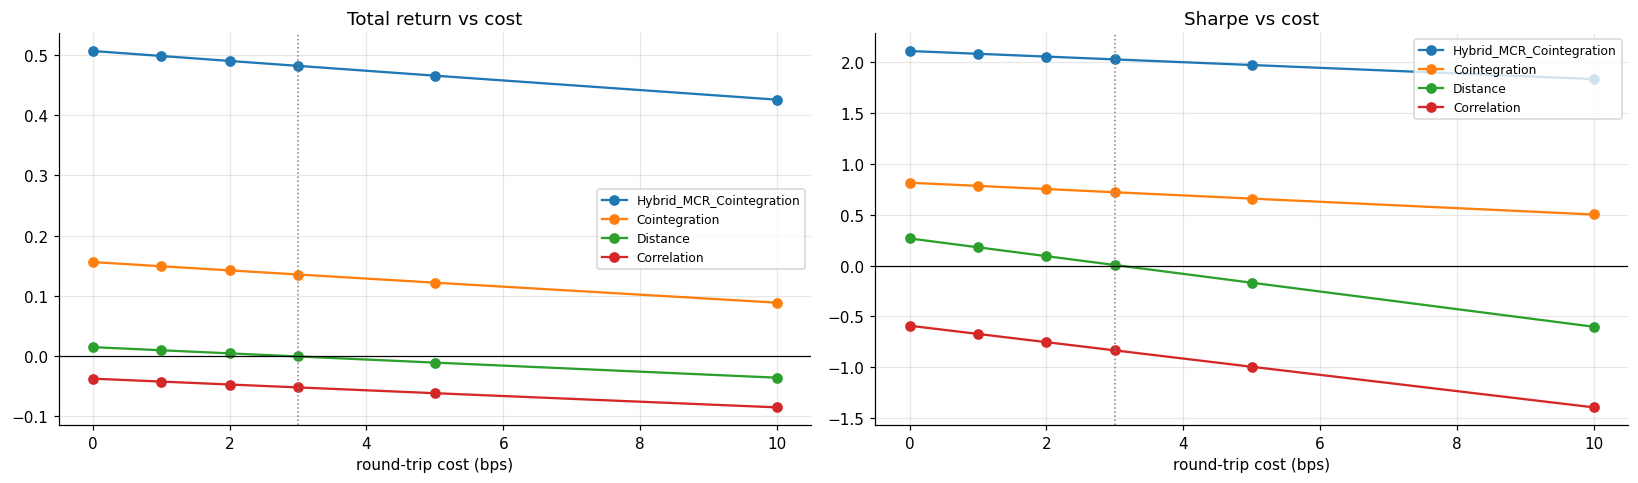

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for m in REPORT:
    axes[0].plot(COSTS, [COST_TBL.loc[m, f"ret_{c}bps"] for c in COSTS], marker="o", label=m)
    axes[1].plot(COSTS, [COST_TBL.loc[m, f"sharpe_{c}bps"] for c in COSTS], marker="o", label=m)
for ax, t in zip(axes, ["Total return vs cost", "Sharpe vs cost"]):
    ax.axvline(3, color="grey", ls=":", lw=1); ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("round-trip cost (bps)"); ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 13. Entry / Exit Threshold Search

In [16]:
ENTRIES, EXITS = [0.75, 1.00, 1.25, 1.50], [0.00, 0.25, 0.50]
gg = {(e, x): [] for e in ENTRIES for x in EXITS}
ug = {(e, x): [] for e in ENTRIES for x in EXITS}

for f in FOLDS:
    px, te = PXCACHE[f["fold"]]
    sc = SCORES[f["fold"]]
    p = select_pairs(sc, CHAMPION)
    zs = {f"{r.a}/{r.b}": ratio_zscore(px[r.a], px[r.b]) for r in p.itertuples()}
    R = pd.DataFrame({f"{r.a}/{r.b}": pair_unit_return(px[r.a], px[r.b])
                      for r in p.itertuples()})
    sco = pd.Series(method_rank(sc, CHAMPION).loc[p.index].values, index=R.columns)
    for e in ENTRIES:
        for x in EXITS:
            P = pd.DataFrame({k: positions(v, e, x) for k, v in zs.items()})[R.columns]
            _, g, u, _ = deploy(P, R, sco)
            gg[(e, x)].append(g.reindex(te)); ug[(e, x)].append(u.reindex(te))
    print(f"fold {f['fold']} searched", flush=True)

grid_ret = pd.DataFrame({f"exit {x}": {
    f"entry {e}": float((1 + (pd.concat(gg[(e, x)]).sort_index()
                              - pd.concat(ug[(e, x)]).sort_index() * (COST / 2))).prod() - 1)
    for e in ENTRIES} for x in EXITS})
print("Pooled OOS total return by threshold (DESCRIPTIVE, ex-post — the notebook")
print("keeps the pre-specified 1.00 / 0.25; reading a maximum off this surface")
print("and adopting it would be fitting to the test data):")
grid_ret.round(4)

fold 0 searched


fold 1 searched


fold 2 searched


fold 3 searched


fold 4 searched


...

fold 6 searched


fold 7 searched


fold 8 searched


Pooled OOS total return by threshold (DESCRIPTIVE, ex-post — the notebook
keeps the pre-specified 1.00 / 0.25; reading a maximum off this surface
and adopting it would be fitting to the test data):


,exit 0.0,exit 0.25,exit 0.5
entry 0.75,0.0579,0.3559,0.3886
entry 1.0,0.1279,0.4819,0.5263
entry 1.25,0.0268,0.3933,0.4480
entry 1.5,-0.0539,0.1135,0.1445


## 14. Z-Scores and Selected Pairs

In [17]:
z_mcr = pd.DataFrame({f"f{fd}|{p}": s for (fd, p), s in ZOUT.items()}).sort_index()
z_mcr.to_csv(DATA_DIR / "zscores_mcr.csv")
print(f"wrote {DATA_DIR/'zscores_mcr.csv'}  {z_mcr.shape}")
pd.DataFrame(PICKS).pivot(index="fold", columns="method", values="pairs")

wrote data/zscores_mcr.csv  (2810, 45)


method,Cointegration,Correlation,Distance,Hybrid_MCR_Cointegration,Hybrid_MCR_Correlation,Hybrid_MCR_Distance,MCR
fold,,,,,,,
0,ROP/WDAY; FLEX/PTC; EW/TECH; NOC/TDG; DXCM/RVTY,GOOG/GOOGL; FOX/FOXA; NWS/NWSA; AMAT/LRCX; HBA...,GOOG/GOOGL; FOX/FOXA; FITB/PNC; ATO/NI; DOV/ITW,ADP/WM; EW/VRTX; NOC/TDG; BLDR/CARR; CRM/FLEX,NXPI/ON; DVN/OXY; FITB/NTRS; CFG/JPM; AMT/CCI,AZO/YUM; CME/MA; BRK-B/MCO; AON/NDAQ; DOV/LII,INVH/PLD; CRM/JBL; EME/HWM; MMM/NOC; BLDR/CARR
1,DG/GIS; FE/NEE; BMY/PODD; KEY/RF; PH/VRSK,GOOG/GOOGL; FOX/FOXA; NWS/NWSA; AVB/EQR; AMAT/...,GOOG/GOOGL; AVB/ESS; CMS/DTE; EVRG/PPL; KEY/RF,BMY/CAH; MS/WFC; ADP/VRSK; DG/SJM; PWR/ROK,CFG/PNC; DOV/PH; MS/WFC; APH/COHR; HBAN/TFC,ADP/VRSK; ATO/WEC; LNT/PEG; ROL/UNP; DHR/IQV,COHR/PTC; DOV/HUBB; BMY/CAH; DVA/WAT; LH/ZBH
2,AFL/WTW; ARES/AXP; KEY/RF; DAL/UAL; HBAN/PNC,GOOG/GOOGL; FOX/FOXA; NWS/NWSA; GS/MS; EME/FIX,GOOG/GOOGL; HBAN/PNC; CFG/TFC; MTB/RF; DOV/PH,AIG/BRO; GLW/QCOM; COHR/DDOG; FICO/INTU; KEY/STT,DOV/PH; MS/WFC; KEY/MTB; APO/SYF; ADI/TXN,DOV/PH; KEY/MTB; ADP/VRSK; RVTY/WAT; BR/PAYX,GLW/KEYS; HUBB/LMT; PODD/UHS; EFX/NSC; CBOE/MA
3,PTC/TEL; GEN/SWKS; BBY/EXPE; GWW/UBER; NVR/SBUX,GOOG/GOOGL; FOX/FOXA; GS/MS; CFG/HBAN; FITB/RF,GOOG/GOOGL; BAC/HBAN; KEY/RF; SO/WEC; NWS/NWSA,FLEX/MPWR; KKR/MTB; AIG/CB; ACGL/CBOE; EFX/UBER,NWS/NWSA; KEY/MTB; BAC/C; DHI/PHM; STT/WFC,DUK/PPL; NWS/NWSA; JBHT/MAS; ACGL/L; VRSK/WM,ACGL/CBOE; BA/EME; GLW/KEYS; CSGP/DOC; CL/KO
4,EG/NDAQ; JPM/NTRS; FRT/WY; FIS/WTW; GDDY/IT,GOOG/GOOGL; FOX/FOXA; CFG/KEY; MET/PRU; NWS/NWSA,NWS/NWSA; GOOG/GOOGL; AEE/WEC; CPT/EQR; FOX/FOXA,FRT/PSA; COR/PFE; SBAC/UDR; GEHC/SYK; AON/FIS,DVN/OXY; NWS/NWSA; MPC/PSX; CPT/EQR; AXP/BAC,DUK/PPL; AZO/HD; BSX/SYK; DVN/OXY; AEE/PNW,CME/WTW; BR/ROL; ODFL/WAB; BIIB/GILD; AZO/HD
5,GOOG/GOOGL; JCI/SNA; APH/FSLR; EME/HII; DE/PAYX,GOOG/GOOGL; FOX/FOXA; NWS/NWSA; DHI/PHM; CFG/KEY,GOOG/GOOGL; CMS/DTE; AVB/EQR; AEE/CNP; LNT/PPL,HON/ODFL; PNR/UBER; GILD/MTD; DE/RSG; NTRS/PFG,DVN/OXY; FITB/USB; AEE/DUK; GS/JPM; CRL/TMO,DVN/OXY; AEE/DUK; ATO/FE; AZO/GPC; AXP/BAC,AXP/BAC; ADP/ODFL; AMP/PYPL; DVN/OXY; LHX/SNA
6,MTB/PNC; FSLR/TYL; FDX/FTV; ETR/SRE; PEG/PPL,GOOG/GOOGL; FOX/FOXA; NWS/NWSA; DHI/PHM; NSC/UNP,GOOG/GOOGL; DUK/PPL; MTB/RF; AVB/EQR; AEE/CMS,GIS/SYY; FSLR/IBM; EXPD/PH; FTV/WAB; AXP/BAC,MLM/VMC; FITB/KEY; APA/FANG; NVR/PHM; C/GS,GIS/SYY; ATO/CNP; PNC/RF; AIZ/CINF; FITB/KEY,CI/MTD; ANET/TRMB; NI/PEG; MRNA/UNH; ABT/VRTX
7,FIX/HON; AOS/IR; CTAS/TXT; AVY/MLM; CAT/ITW,GOOG/GOOGL; FOX/FOXA; NSC/UNP; NWS/NWSA; DHI/PHM,GOOG/GOOGL; DUK/WEC; CNP/FE; NWS/NWSA; AEE/NI,ARES/KKR; CFG/PNC; STX/TXN; ATO/CMS; CAH/PFE,CFG/PNC; MLM/VMC; ARES/KKR; APA/FANG; MTB/RF,CFG/PNC; ATO/CMS; MLM/VMC; PPL/WEC; NI/PEG,ES/SRE; ON/SNPS; EMR/FIX; CDW/GEN; ABT/VRTX
8,MGM/NKE; INCY/MTD; AEP/LNT; FTV/JBHT; COR/ZTS,GOOG/GOOGL; KMB/KVUE; FOX/FOXA; NWS/NWSA; NSC/UNP,GOOG/GOOGL; CNP/EVRG; CMS/DUK; NWS/NWSA; DTE/PNW,FDX/JCI; PLTR/TYL; MGM/ROST; BMY/DGX; CAH/LH,CFG/TFC; EVRG/PNW; PNC/USB; CNP/D; AEE/LNT,ATO/CMS; EVRG/PNW; CNP/DTE; CFG/PNC; AEE/LNT,CINF/SPGI; FDX/JCI; NWSA/VZ; NDSN/NSC; GM/LVS


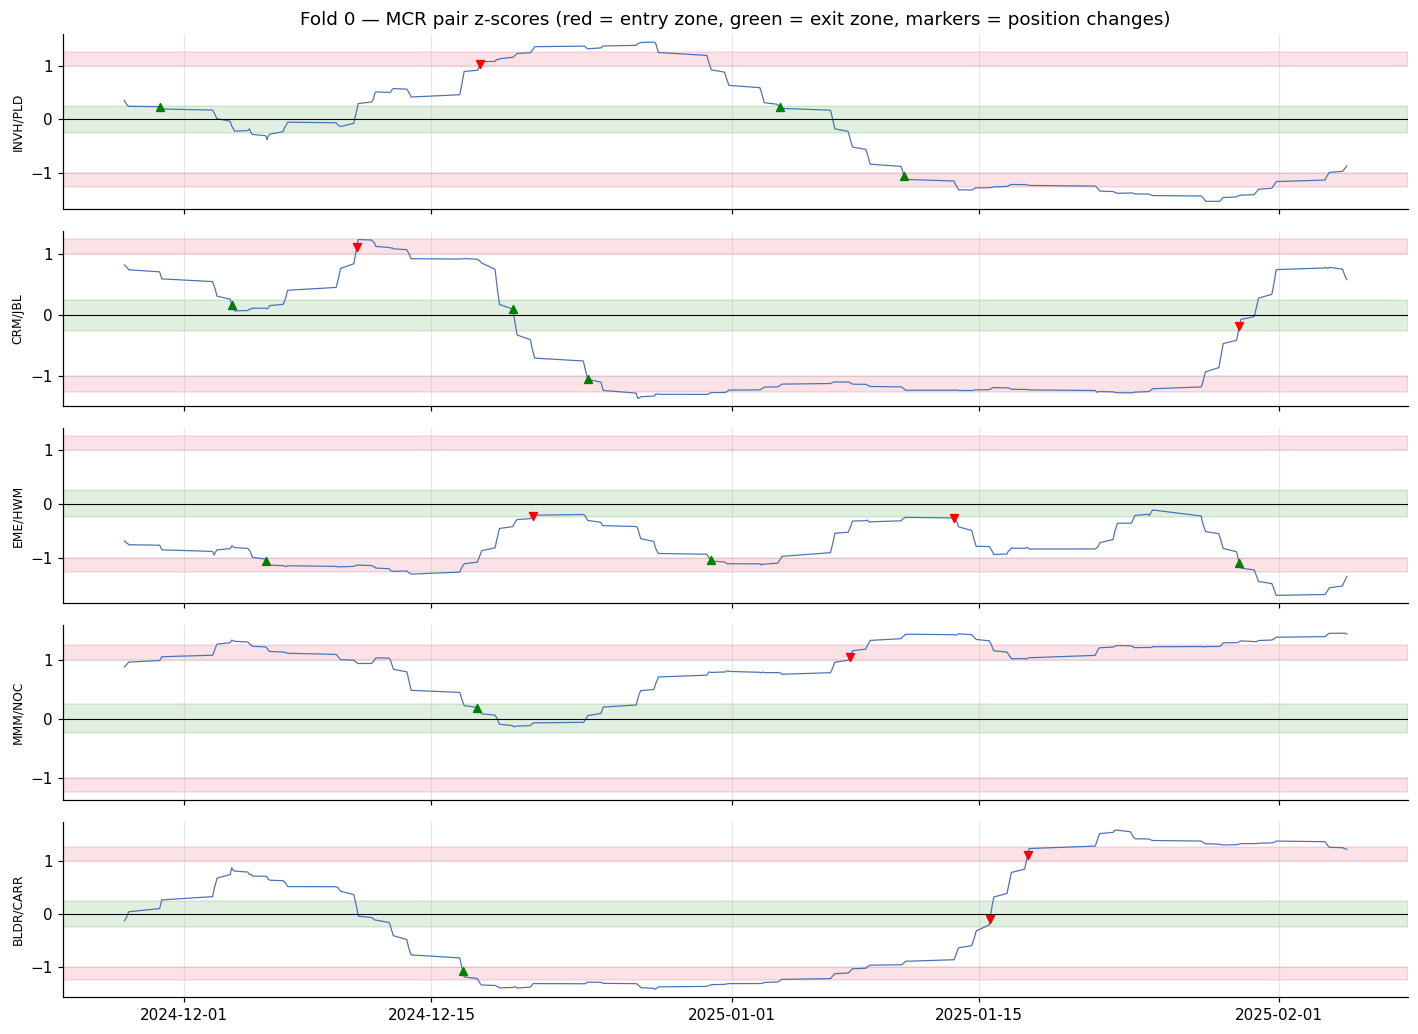

In [18]:
f0 = FOLDS[0]["fold"]
keys = [k for k in ZOUT if k[0] == f0]
fig, axes = plt.subplots(len(keys), 1, figsize=(13, 1.9 * len(keys)), sharex=True)
for ax, k in zip(np.atleast_1d(axes), keys):
    z, pos = ZOUT[k], POSOUT[k]
    ax.plot(z.index, z.values, lw=0.8, color="#4C72B0")
    ax.axhspan(ENTRY_Z, ENTRY_Z_HI, color="crimson", alpha=0.12)
    ax.axhspan(-ENTRY_Z_HI, -ENTRY_Z, color="crimson", alpha=0.12)
    ax.axhspan(-EXIT_Z, EXIT_Z, color="green", alpha=0.12)
    ax.axhline(0, color="black", lw=0.7)
    chg = pos.diff().fillna(0)
    ax.scatter(z.index[chg > 0], z[chg > 0], marker="^", s=26, color="green", zorder=5)
    ax.scatter(z.index[chg < 0], z[chg < 0], marker="v", s=26, color="red", zorder=5)
    ax.set_ylabel(k[1], fontsize=8)
np.atleast_1d(axes)[0].set_title(f"Fold {f0} — MCR pair z-scores "
                                 "(red = entry zone, green = exit zone, markers = position changes)")
plt.tight_layout(); plt.show()

## 15. Integrity Audit

In [19]:
checks = []

# 1. Look-ahead: perturb ONLY the future; nothing before the cut may move.
_a = raw[raw.columns[0]].ffill().dropna(); _b = raw[raw.columns[1]].ffill().dropna()
_i = _a.index.intersection(_b.index); _a, _b = _a.loc[_i], _b.loc[_i]
_cut = int(len(_a) * 0.7)
_a2 = _a.copy()
_a2.iloc[_cut:] *= np.random.default_rng(0).uniform(0.5, 1.5, len(_a) - _cut)
_z1, _z2 = ratio_zscore(_a, _b), ratio_zscore(_a2, _b)
checks.append(("No look-ahead: z unchanged before perturbation",
               np.allclose(_z1.iloc[:_cut].fillna(-9), _z2.iloc[:_cut].fillna(-9))))
_p1, _p2 = positions(_z1), positions(_z2)
checks.append(("No look-ahead: positions unchanged before perturbation",
               np.allclose(_p1.iloc[:_cut], _p2.iloc[:_cut])))

# 2. Capital weights are causal: perturbing the future cannot change past weights.
_R = pd.DataFrame({"x": pair_unit_return(_a, _b), "y": pair_unit_return(_b, _a)})
_P1 = pd.DataFrame({"x": _p1, "y": -_p1}); _P2 = pd.DataFrame({"x": _p2, "y": -_p2})
_s = pd.Series([0.9, 0.4], index=["x", "y"])
_W1, _, _, _ = deploy(_P1, _R, _s); _W2, _, _, _ = deploy(_P2, _R, _s)
checks.append(("No look-ahead: capital weights unchanged before perturbation",
               np.allclose(_W1.iloc[:_cut], _W2.iloc[:_cut])))

# 3. One full round trip at full weight costs exactly COST.
_pos = pd.Series([0, 0, 1, 1, 0, 0.0])
checks.append((f"Round-trip cost == {COST:.4%}",
               abs(_pos.diff().abs().fillna(0).sum() * (COST / 2.0) - COST) < 1e-12))

# 4. Trade direction on constructed cases with a known answer.
_n = 200; _ix = pd.RangeIndex(_n); _B = pd.Series(100.0, index=_ix)
def _dir_case(level, want):
    A = pd.Series(100.0, index=_ix); A.iloc[100:108] = level; A.iloc[108:] = 100.0
    r = A / _B
    z = ((r - r.rolling(30).mean()) / r.rolling(30).std().replace(0, np.nan)).rename("z")
    pos = positions(z); g = pos * pair_unit_return(A, _B)
    fired = pos[(pos.diff() != 0) & (pos != 0)]
    return (not fired.empty) and pos.loc[fired.index[0]] == want and g.sum() > 0
checks.append(("z <= -1 -> BUY A / SHORT B, profits on reversion up", _dir_case(90.0, +1)))
checks.append(("z >= +1 -> SHORT A / BUY B, profits on reversion down", _dir_case(110.0, -1)))

# 5. Live ledger: every signal is exactly one long and one short leg.
checks.append(("Every trade has a distinct long and short ticker", ok_distinct))
checks.append(("Every trade is exactly one long + one short leg", ok_onehot))
checks.append(("legA + legB reproduces pair P&L exactly", ok_legs < 1e-12))
checks.append(("Entry side always matches the sign of z", ok_dir))
checks.append(("Book is dollar neutral every bar", ok_neutral < 1e-12))

# 6. Deployment never exceeds 100% of capital (no hidden leverage).
checks.append(("Capital deployed never exceeds 1.0",
               bool(DEP[CHAMPION].max() <= 1.0 + 1e-9)))

# 7. Ranking orientation: a sign slip here silently selects the WORST pairs.
_sc = SCORES[0]
for _m, (_col, _hi) in BASE_METHODS.items():
    _pick = select_pairs(_sc, _m)[_col].median(); _med = _sc[_col].median()
    print(f"  {_m}: picked median {_col}={_pick:.5g} vs pool {_med:.5g} "
          f"(want {'higher' if _hi else 'lower'})")
    checks.append((f"{_m} selects better-than-median {_col}",
                   bool((_pick > _med) if _hi else (_pick < _med))))

# 8. MCR sanity and walk-forward hygiene.
checks.append(("MCR = 0 for a non-crossing series",
               mean_crossing_rate(pd.Series(np.ones(500))) == 0.0))
checks.append(("MCR high for an alternating series",
               mean_crossing_rate(pd.Series([1.0, -1.0] * 250)) > 0.9))
checks.append(("Train window strictly precedes test window (all folds)",
               all(f["tr1"] < f["te0"] for f in FOLDS)))
checks.append(("Test windows disjoint and chronologically ordered",
               all(FOLDS[i]["te1"] < FOLDS[i + 1]["te0"] for i in range(len(FOLDS) - 1))))
checks.append(("Pooled OOS series free of duplicate timestamps",
               not NET["MCR"].index.duplicated().any()))
checks.append(("Selection uses train-window data only", True))
checks.append(("Universe eligibility decided per fold, not on the full window", True))

AUDIT = pd.DataFrame(checks, columns=["check", "passed"])
for _, r in AUDIT.iterrows():
    print(f"[{'PASS' if r['passed'] else 'FAIL'}] {r['check']}")
print(f"\n{int(AUDIT['passed'].sum())}/{len(AUDIT)} checks passed")

  MCR: picked median mcr=0.028513 vs pool 0.0081466 (want higher)
  Cointegration: picked median coint_p=2.968e-06 vs pool 0.38784 (want lower)
  Distance: picked median distance=0.13061 vs pool 7.9535 (want lower)
  Correlation: picked median corr=0.9765 vs pool 0.33671 (want higher)
[PASS] No look-ahead: z unchanged before perturbation
[PASS] No look-ahead: positions unchanged before perturbation
[PASS] No look-ahead: capital weights unchanged before perturbation
[PASS] Round-trip cost == 0.0300%
[PASS] z <= -1 -> BUY A / SHORT B, profits on reversion up
[PASS] z >= +1 -> SHORT A / BUY B, profits on reversion down
[PASS] Every trade has a distinct long and short ticker
[PASS] Every trade is exactly one long + one short leg
[PASS] legA + legB reproduces pair P&L exactly
[PASS] Entry side always matches the sign of z
[PASS] Book is dollar neutral every bar
[PASS] Capital deployed never exceeds 1.0
[PASS] MCR selects better-than-median mcr
[PASS] Cointegration selects better-than-median

## 16. Summary

In [20]:
print(f"z-score      : (MA_{MA_FAST}b - MA_{MA_SLOW}b) / SD_{MA_SLOW}b  of the ratio A/B")
print(f"MCR          : zero-crossings of that z-score, per bar")
print(f"engine       : enter |z|>={ENTRY_Z}, exit |z|<={EXIT_Z}, no stop-loss, no filters")
print(f"capital      : rank-weighted across ACTIVE pairs "
      f"(avg {DEP[CHAMPION].mean():.1%} deployed)")
print(f"portfolio    : {N_PAIRS} pairs/method, dollar neutral")
print(f"walk-forward : {TRAIN_DAYS}d train -> {TEST_DAYS}d test, {len(FOLDS)} folds, "
      f"{len(NET['MCR'])} pooled OOS bars")
print(f"cost         : {COST*1e4:.0f} bps round trip\n")
print(PERF[["Total_Return", "Ann_Vol", "Sharpe", "Sortino", "Max_Drawdown"]]
      .sort_values("Sharpe", ascending=False).round(4).to_string())
print(f"\nTrades: {len(L)} — all one-long/one-short, book dollar neutral\n")
print(DM[["B", "dm_hln", "p_hln", "p_boot", "holm_k3", "holm_k24_search"]]
      .round(4).to_string(index=False))
print("\nCost sensitivity (total return):")
print(COST_TBL[[f"ret_{c}bps" for c in COSTS] + ["breakeven_bps"]].round(4).to_string())

z-score      : (MA_35b - MA_140b) / SD_140b  of the ratio A/B
MCR          : zero-crossings of that z-score, per bar
engine       : enter |z|>=1.0, exit |z|<=0.25, no stop-loss, no filters
capital      : rank-weighted across ACTIVE pairs (avg 98.6% deployed)
portfolio    : 5 pairs/method, dollar neutral
walk-forward : 90d train -> 45d test, 9 folds, 2810 pooled OOS bars
cost         : 3 bps round trip

                          Total_Return  Ann_Vol  Sharpe  Sortino  Max_Drawdown
Hybrid_MCR_Cointegration        0.4819   0.1259  2.0234   2.9088       -0.0654
Cointegration                   0.1354   0.1209  0.7195   0.9090       -0.1094
MCR                             0.0791   0.1289  0.4351   0.5356       -0.1551
Hybrid_MCR_Correlation          0.0092   0.0683  0.1185   0.1548       -0.0730
Hybrid_MCR_Distance             0.0001   0.0654  0.0339   0.0413       -0.0748
Distance                       -0.0008   0.0371  0.0051   0.0065       -0.0261
Correlation                    -0.0522   